# ADS1001 Project Report Notebook

**Project title:** Communicating Useful Weather Indicators for Public Weather Guidance in Malaysia

**Group members:**

- XU ZIHAO
- Huang Qingyue
- TAY CHEN ZHE
- CHEN ZIMO
- LI YIMING


## Project Background

### Project Aim

To help a Malaysian public weather information service identify the most useful weather indicators for communicating outdoor comfort, UV risk, rainfall conditions, and changing weather patterns to the public.

### Client

The client is a Malaysian public weather information service that provides weather guidance to residents, commuters, and outdoor users.

### Client Problem

The client currently has access to multiple weather variables, but these raw measurements are difficult for the public to interpret directly. The client needs to know which variables are most useful for communicating outdoor comfort, UV exposure risk, rainfall conditions, and changing weather patterns.

### Our Response

To address this need, the group investigates five linked research questions. The first checks whether the cleaned dataset is reliable and geographically clear enough to support the analysis. The remaining questions evaluate the practical communication value of temperature, wind chill, humidity, dew point, pressure trend, rainfall, and UV Index.

This final report integrates the five group notebooks into one coherent analysis. The aim is not to report every variable equally, but to decide which indicators are most useful for a public-facing weather information service.

**Integrated source notebooks:**

| Source notebook | Contribution to this final notebook |
|---|---|
| `malaysia_weather_data_cleaning_process.ipynb` | Cleaning process, missing-value handling, duplicate checks, timestamp construction, and validation logic |
| `ADS1001 notebook Q1.ipynb` | Temperature versus wind chill analysis |
| `weather_project.ipynb` | Humidity, dew point, and oppressive weather analysis |
| `ADS1001_updated_with_cleaned_data.ipynb` | Atmospheric pressure, pressure trend, rainfall analysis, and optional predictive model |
| `xu_zihao_uv_index_analysis.ipynb` | UV Index risk categories and public warning thresholds |


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

try:
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        average_precision_score,
        confusion_matrix,
    )
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

PROJECT_ROOT = Path.cwd()


## 2. Introduction & Research Questions

Malaysia's weather communication problem is not just about reporting many variables. A public-facing service needs indicators that are understandable, useful, and connected to realistic actions. The same dataset contains temperature, wind chill, humidity, dew point, atmospheric pressure, rainfall, wind, and UV Index readings, but not all of these variables are equally useful for public guidance.

This final notebook integrates the group analyses into one report. The shared objective is to evaluate which weather indicators should be emphasised for different public communication needs.

**Research questions**

1. Is the cleaned dataset valid, complete, and geographically clear enough to support public weather communication analysis?
2. How different are temperature and wind chill readings in Malaysia, and does wind chill add practical value beyond temperature?
3. How strongly are humidity and dew point associated, and which variable better describes oppressive, sticky weather?
4. How are atmospheric pressure and pressure changes associated with rainfall, and can pressure trend support short-term rain guidance?
5. Which weather conditions correspond to high UV Index values, and what threshold should trigger public UV warnings?

**Overall hypothesis:** A useful public weather dashboard should prioritise indicators that are both interpretable and actionable. Temperature, dew point or heat discomfort, rainfall risk, pressure trend, and UV Index are expected to provide complementary information, while wind chill is expected to add little value in a tropical climate.


In [2]:
project_questions = pd.DataFrame({
    'Research question': [1, 2, 3, 4, 5],
    'Section': [
        'Data quality and coverage',
        'Temperature and wind chill',
        'Humidity and dew point',
        'Pressure and rainfall',
        'UV Index warnings',
    ],
    'Public communication decision': [
        'Is the cleaned dataset reliable enough for public weather analysis?',
        'Should wind chill be highlighted alongside temperature?',
        'Should humidity or dew point be used to describe oppressive weather?',
        'Can pressure trend help flag possible upcoming rainfall?',
        'When should UV reminders and warnings be issued?',
    ],
    'Main variables': [
        'location fields, timestamp fields, missingness, duplicates, outliers',
        'temperature, wind_chill, wind_speed',
        'temperature, humidity, dew_point, derived heat_index',
        'pressure, pressure_change, precipitation_rate, rain_event',
        'uv_index, temperature, humidity, rainfall, hour',
    ]
})
project_questions


,Research question,Section,Public communication decision,Main variables
0,1,Data quality and coverage,Is the cleaned dataset reliable enough for pub...,"location fields, timestamp fields, missingness..."
1,2,Temperature and wind chill,Should wind chill be highlighted alongside tem...,"temperature, wind_chill, wind_speed"
2,3,Humidity and dew point,Should humidity or dew point be used to descri...,"temperature, humidity, dew_point, derived heat..."
3,4,Pressure and rainfall,Can pressure trend help flag possible upcoming...,"pressure, pressure_change, precipitation_rate,..."
4,5,UV Index warnings,When should UV reminders and warnings be issued?,"uv_index, temperature, humidity, rainfall, hour"


## 3. Data Dictionary

The formal weather data dictionary describes the units for temperature, pressure, dew point, humidity, wind, gust, wind chill, UV Index, and precipitation. The table below combines those definitions with the role each column plays in this final analysis and the broad rational checks used later for plausibility screening.


In [3]:
data_dictionary = pd.DataFrame([
    {'Column': 'place', 'Type': 'Categorical', 'Unit': 'Not applicable', 'Meaning': 'Specific observation place or station label', 'Expected / rational range': 'Non-empty text', 'Role in project': 'Location grouping and coverage checks'},
    {'Column': 'city', 'Type': 'Categorical', 'Unit': 'Not applicable', 'Meaning': 'City where the observation was recorded', 'Expected / rational range': 'Non-empty text', 'Role in project': 'Location grouping and coverage checks'},
    {'Column': 'state', 'Type': 'Categorical', 'Unit': 'Not applicable', 'Meaning': 'State where the observation was recorded', 'Expected / rational range': 'Non-empty text', 'Role in project': 'Location grouping and coverage checks'},
    {'Column': 'temperature', 'Type': 'Numerical', 'Unit': 'degrees C', 'Meaning': 'Air temperature', 'Expected / rational range': '0 to 45 for Malaysian weather screening', 'Role in project': 'Main thermal headline and UV context'},
    {'Column': 'pressure', 'Type': 'Numerical', 'Unit': 'hPa / millibars', 'Meaning': 'Atmospheric pressure', 'Expected / rational range': '950 to 1050', 'Role in project': 'Rainfall and pressure-trend analysis'},
    {'Column': 'dew_point', 'Type': 'Numerical', 'Unit': 'degrees C', 'Meaning': 'Dew point temperature', 'Expected / rational range': '0 to 35', 'Role in project': 'Moisture and oppressive-weather indicator'},
    {'Column': 'humidity', 'Type': 'Numerical', 'Unit': 'percent', 'Meaning': 'Relative humidity', 'Expected / rational range': '0 to 100', 'Role in project': 'Moisture and heat context'},
    {'Column': 'wind_speed', 'Type': 'Numerical', 'Unit': 'm/s or km/h in source dictionary', 'Meaning': 'Wind speed', 'Expected / rational range': '0 or greater', 'Role in project': 'Wind chill and rainfall context'},
    {'Column': 'gust', 'Type': 'Numerical', 'Unit': 'm/s or km/h in source dictionary', 'Meaning': 'Sudden increase in wind speed', 'Expected / rational range': '0 or greater', 'Role in project': 'Outdoor condition context'},
    {'Column': 'wind_chill', 'Type': 'Numerical', 'Unit': 'degrees C', 'Meaning': 'Wind chill reading', 'Expected / rational range': '0 to 45 for Malaysian weather screening', 'Role in project': 'Comparison with temperature'},
    {'Column': 'uv_index', 'Type': 'Numerical', 'Unit': 'UV Index scale', 'Meaning': 'Intensity of ultraviolet radiation from the sun', 'Expected / rational range': '0 or greater; 11+ is extreme', 'Role in project': 'UV warning analysis'},
    {'Column': 'precipitation_rate', 'Type': 'Numerical', 'Unit': 'mm/h or mm/day in source dictionary', 'Meaning': 'Current precipitation intensity', 'Expected / rational range': '0 or greater', 'Role in project': 'Rainfall event analysis'},
    {'Column': 'precipitation_total', 'Type': 'Numerical', 'Unit': 'millimetres in source dictionary', 'Meaning': 'Accumulated precipitation total', 'Expected / rational range': '0 or greater', 'Role in project': 'Rainfall event analysis'},
    {'Column': 'year', 'Type': 'Integer', 'Unit': 'year', 'Meaning': 'Observation year', 'Expected / rational range': 'Calendar year', 'Role in project': 'Time coverage'},
    {'Column': 'month', 'Type': 'Categorical', 'Unit': 'month label', 'Meaning': 'Three-letter month label', 'Expected / rational range': 'Jan to Dec', 'Role in project': 'Time coverage'},
    {'Column': 'day', 'Type': 'Integer', 'Unit': 'day', 'Meaning': 'Day of month', 'Expected / rational range': '1 to 31, depending on month', 'Role in project': 'Time coverage'},
    {'Column': 'hour', 'Type': 'Integer', 'Unit': 'hour', 'Meaning': 'Hour of day', 'Expected / rational range': '0 to 23', 'Role in project': 'Hourly and UV patterns'},
    {'Column': 'minutes', 'Type': 'Integer', 'Unit': 'minute', 'Meaning': 'Minute of observation', 'Expected / rational range': '0 to 59', 'Role in project': 'Timestamp construction'},
    {'Column': 'seconds', 'Type': 'Integer', 'Unit': 'second', 'Meaning': 'Second of observation', 'Expected / rational range': '0 to 59', 'Role in project': 'Timestamp construction'},
    {'Column': 'month_number', 'Type': 'Integer', 'Unit': 'month number', 'Meaning': 'Numeric month created during preprocessing', 'Expected / rational range': '1 to 12', 'Role in project': 'Timestamp construction and sorting'},
    {'Column': 'datetime', 'Type': 'Date/Time', 'Unit': 'timestamp', 'Meaning': 'Combined timestamp created during preprocessing', 'Expected / rational range': 'Valid timestamp', 'Role in project': 'Time-series and trend analysis'},
])
data_dictionary


,Column,Type,Unit,Meaning,Expected / rational range,Role in project
0,place,Categorical,Not applicable,Specific observation place or station label,Non-empty text,Location grouping and coverage checks
1,city,Categorical,Not applicable,City where the observation was recorded,Non-empty text,Location grouping and coverage checks
2,state,Categorical,Not applicable,State where the observation was recorded,Non-empty text,Location grouping and coverage checks
3,temperature,Numerical,degrees C,Air temperature,0 to 45 for Malaysian weather screening,Main thermal headline and UV context
4,pressure,Numerical,hPa / millibars,Atmospheric pressure,950 to 1050,Rainfall and pressure-trend analysis
5,dew_point,Numerical,degrees C,Dew point temperature,0 to 35,Moisture and oppressive-weather indicator
6,humidity,Numerical,percent,Relative humidity,0 to 100,Moisture and heat context
7,wind_speed,Numerical,m/s or km/h in source dictionary,Wind speed,0 or greater,Wind chill and rainfall context
8,gust,Numerical,m/s or km/h in source dictionary,Sudden increase in wind speed,0 or greater,Outdoor condition context
9,wind_chill,Numerical,degrees C,Wind chill reading,0 to 45 for Malaysian weather screening,Comparison with temperature


## 4. Executive Summary

The integrated analysis supports a clear public communication strategy:

- **Temperature should remain the main thermal headline.** Wind chill is almost identical to temperature in the available Malaysian observations, so it adds little practical value for routine public guidance.
- **Dew point is a stronger comfort signal than humidity alone.** Humidity and dew point are positively associated, but humidity is strongly affected by temperature. Dew point better represents actual moisture in the air and is more useful for describing muggy conditions.
- **Pressure trend can support rain guidance, but it should not be used alone.** Falling pressure has a modest link with next-observation rain probability, while humidity, temperature, time of day, and recent rain patterns also matter. The predictive model is useful as a supporting warning tool rather than a standalone forecast.
- **UV Index needs direct public warnings.** High UV values are concentrated from late morning to mid-afternoon. A public UV warning should begin at **UV Index >= 6**, with a lighter reminder at **UV Index >= 3** and stronger alerts at **UV Index >= 8**.

Overall, the best public-facing weather dashboard should prioritise **temperature, dew point or heat discomfort, rainfall risk, and UV Index**, while treating wind chill and pressure as supporting context.


## 5. Data Loading

The notebook loads both the original raw CSV and the final cleaned CSV when both files are available. The raw file is used only for audit checks, while all analysis and modelling use the cleaned final file `data/malaysia_weather_cleaned_file.csv`.


In [4]:
EXPECTED_COLUMNS = {
    'place', 'city', 'state', 'temperature', 'pressure', 'dew_point', 'humidity',
    'wind_speed', 'gust', 'wind_chill', 'uv_index', 'precipitation_rate',
    'precipitation_total', 'year', 'month', 'day', 'hour', 'minutes', 'seconds',
    'month_number', 'datetime'
}

candidate_paths = [
    PROJECT_ROOT / 'data' / 'malaysia_weather_cleaned_file.csv',
    PROJECT_ROOT / 'data' / 'malaysia_weather_cleaned_file(3).csv',
    PROJECT_ROOT / 'malaysia_weather_cleaned_file.csv',
    Path('/Users/c2/Desktop/malaysia_weather_cleaned_file(3).csv'),
]
raw_candidate_paths = [
    PROJECT_ROOT / 'malaysia_weather_data.csv',
    PROJECT_ROOT / 'data' / 'malaysia_weather_data.csv',
]


def load_cleaned_weather_csv(paths):
    """Load the cleaned weather CSV from the first valid path in a candidate list."""
    for path in paths:
        if path.exists():
            df_candidate = pd.read_csv(path, low_memory=False)
            if EXPECTED_COLUMNS.issubset(set(df_candidate.columns)):
                return path, df_candidate
            raise ValueError(f'Found {path}, but it does not contain the expected cleaned weather columns.')
    raise FileNotFoundError('Cleaned weather CSV not found. Place malaysia_weather_cleaned_file.csv in the data folder.')


def load_optional_raw_weather_csv(paths):
    """Load the original raw weather CSV when it is available for cleaning-audit comparisons."""
    for path in paths:
        if path.exists():
            return path, pd.read_csv(path, low_memory=False)
    return None, None


DATA_PATH, raw_df = load_cleaned_weather_csv(candidate_paths)
RAW_DATA_PATH, raw_source_df = load_optional_raw_weather_csv(raw_candidate_paths)

print(f'Loaded cleaned dataset from: {DATA_PATH}')
print(f'Cleaned dataset shape: {raw_df.shape}')
if raw_source_df is not None:
    print(f'Loaded raw dataset from: {RAW_DATA_PATH}')
    print(f'Raw dataset shape: {raw_source_df.shape}')

display(raw_df.head())

raw_cleaning_audit_rows = []
if raw_source_df is not None:
    raw_cleaning_audit_rows.append({
        'Dataset stage': 'Raw source file',
        'Rows': len(raw_source_df),
        'Columns': raw_source_df.shape[1],
        'Duplicate rows': int(raw_source_df.duplicated().sum()),
        'Total missing values': int(raw_source_df.isna().sum().sum()),
    })
raw_cleaning_audit_rows.append({
    'Dataset stage': 'Cleaned final file',
    'Rows': len(raw_df),
    'Columns': raw_df.shape[1],
    'Duplicate rows': int(raw_df.duplicated().sum()),
    'Total missing values': int(raw_df.isna().sum().sum()),
})
raw_cleaning_audit = pd.DataFrame(raw_cleaning_audit_rows)
display(raw_cleaning_audit)

if raw_source_df is not None:
    compared_columns = [col for col in raw_source_df.columns if col in raw_df.columns]
    missing_comparison = pd.DataFrame({
        'Column': compared_columns,
        'Raw missing count': [int(raw_source_df[col].isna().sum()) for col in compared_columns],
        'Cleaned missing count': [int(raw_df[col].isna().sum()) for col in compared_columns],
    })
    missing_comparison['Missing values resolved'] = (
        missing_comparison['Raw missing count'] - missing_comparison['Cleaned missing count']
    )
    display(missing_comparison.sort_values('Raw missing count', ascending=False).head(12))


Loaded cleaned dataset from: /Users/c2/Library/CloudStorage/GoogleDrive-zche0400@student.monash.edu/My Drive/ADS1001/project/MWF-G2/data/malaysia_weather_cleaned_file.csv
Cleaned dataset shape: (51693, 21)
Loaded raw dataset from: /Users/c2/Library/CloudStorage/GoogleDrive-zche0400@student.monash.edu/My Drive/ADS1001/project/MWF-G2/malaysia_weather_data.csv
Raw dataset shape: (57475, 19)


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds,month_number,datetime
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,30.300,"1,015.325",25.100,73.700,0.900,1.500,30.300,1.000,0.000,0.000,2022,Sep,23,13,54,57,9,2022-09-23 13:54:57
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,27.000,"1,000.680",25.600,92.000,5.200,5.300,27.000,0.000,0.000,17.780,2023,May,4,19,9,59,5,2023-05-04 19:09:59
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,26.400,"1,013.550",26.300,99.000,0.000,0.000,26.400,0.000,0.000,32.000,2021,Oct,23,23,44,43,10,2021-10-23 23:44:43
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,31.100,"1,005.420",30.900,99.000,0.000,0.000,31.100,0.000,0.000,0.000,2021,Mar,21,18,9,47,3,2021-03-21 18:09:47
4,Penang Road,George Town,Pulau Pinang,25.800,"1,007.790",23.900,88.000,6.400,16.100,25.800,0.000,0.000,0.000,2022,Dec,22,7,0,23,12,2022-12-22 07:00:23


,Dataset stage,Rows,Columns,Duplicate rows,Total missing values
0,Raw source file,57475,19,0,111093
1,Cleaned final file,51693,21,0,0


,Column,Raw missing count,Cleaned missing count,Missing values resolved
10,uv_index,18298,0,18298
8,gust,13284,0,13284
11,precipitation_rate,10901,0,10901
12,precipitation_total,10901,0,10901
5,dew_point,10510,0,10510
9,wind_chill,10150,0,10150
3,temperature,10112,0,10112
6,humidity,10105,0,10105
7,wind_speed,8642,0,8642
4,pressure,8190,0,8190


## 6. Data Cleaning and Validation

The raw-to-cleaned process was completed in the group cleaning notebook, and this final report validates the supplied cleaned file before using it for analysis. The audit above compares the original raw file with the final cleaned file, while the checks below verify that the final file has the expected columns, no duplicate rows, no missing values, and a valid reconstructed timestamp.

Important interpretation note: because this final CSV has already been cleaned and contains no missing values, the notebook treats the values in the file as the final analysis values. Without the full cleaning log inside this notebook, values such as `0` in UV or rainfall fields should be interpreted as cleaned final values, not automatically as originally observed values.


In [5]:
weather_cols = [
    'temperature', 'pressure', 'dew_point', 'humidity', 'wind_speed',
    'gust', 'wind_chill', 'uv_index', 'precipitation_rate', 'precipitation_total'
]
time_cols = ['year', 'month', 'day', 'hour', 'minutes', 'seconds']
location_cols = ['place', 'city', 'state']

analysis_base = raw_df.copy()
for col in weather_cols + ['year', 'day', 'hour', 'minutes', 'seconds', 'month_number']:
    analysis_base[col] = pd.to_numeric(analysis_base[col], errors='coerce')
analysis_base['datetime'] = pd.to_datetime(analysis_base['datetime'], errors='coerce')

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
expected_month_number = analysis_base['month'].map(month_map)
expected_datetime = pd.to_datetime(
    {
        'year': analysis_base['year'],
        'month': analysis_base['month_number'],
        'day': analysis_base['day'],
        'hour': analysis_base['hour'],
        'minute': analysis_base['minutes'],
        'second': analysis_base['seconds'],
    },
    errors='coerce'
)

validation_summary = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Duplicate rows',
        'Total missing values',
        'Missing values in main weather columns',
        'Invalid datetime values',
        'Month-number mismatches',
        'Datetime reconstruction mismatches',
    ],
    'Value': [
        len(analysis_base),
        analysis_base.shape[1],
        int(analysis_base.duplicated().sum()),
        int(analysis_base.isna().sum().sum()),
        int(analysis_base[weather_cols].isna().sum().sum()),
        int(analysis_base['datetime'].isna().sum()),
        int((expected_month_number != analysis_base['month_number']).sum()),
        int((expected_datetime != analysis_base['datetime']).sum()),
    ]
})

coverage_summary = pd.DataFrame({
    'Metric': ['States', 'Cities', 'Places', 'Earliest timestamp', 'Latest timestamp', 'Distinct dates'],
    'Value': [
        analysis_base['state'].nunique(),
        analysis_base['city'].nunique(),
        analysis_base['place'].nunique(),
        analysis_base['datetime'].min(),
        analysis_base['datetime'].max(),
        analysis_base['datetime'].dt.date.nunique(),
    ]
})

display(validation_summary)
display(coverage_summary)


,Metric,Value
0,Rows,51693
1,Columns,21
2,Duplicate rows,0
3,Total missing values,0
4,Missing values in main weather columns,0
5,Invalid datetime values,0
6,Month-number mismatches,0
7,Datetime reconstruction mismatches,0


,Metric,Value
0,States,2
1,Cities,8
2,Places,16
3,Earliest timestamp,2018-01-17 01:00:00
4,Latest timestamp,2023-08-30 15:59:42
5,Distinct dates,1969


## 7. Preprocessing

The analysis uses `analysis_base`, the validated cleaned dataset. A duplicate called `model_ready` is created so that modelling features can be added without changing the validation layer. The cleaned file has no missing weather values; missing flags are still retained in `model_ready` to document the check and to keep the modelling workflow robust if the notebook is rerun with a less complete version of the data.


In [6]:
def hierarchical_median_fill(df: pd.DataFrame, col: str) -> pd.Series:
    """Fill missing numeric weather values using increasingly broad location-time medians."""
    filled = df[col].copy()
    grouping_levels = [
        ['place', 'month_number', 'hour'],
        ['city', 'month_number', 'hour'],
        ['state', 'month_number', 'hour'],
        ['month_number', 'hour'],
        ['state'],
    ]
    for keys in grouping_levels:
        medians = df.groupby(keys, observed=False)[col].transform('median')
        filled = filled.fillna(medians)
    return filled.fillna(df[col].median())


model_ready = analysis_base.copy()
for col in weather_cols:
    model_ready[f'{col}_missing_flag'] = model_ready[col].isna().astype(int)
    model_ready[col] = hierarchical_median_fill(model_ready, col)

preprocessing_summary = pd.DataFrame({
    'Dataset layer': ['analysis_base', 'model_ready'],
    'Purpose': [
        'Observed-data EDA and variable-specific analyses',
        'Predictive modelling where complete numeric predictors are required',
    ],
    'Rows': [len(analysis_base), len(model_ready)],
    'Missing values in main weather columns': [
        int(analysis_base[weather_cols].isna().sum().sum()),
        int(model_ready[weather_cols].isna().sum().sum()),
    ],
    'Missing-flag columns retained': [0, len(weather_cols)],
})

preprocessing_summary


,Dataset layer,Purpose,Rows,Missing values in main weather columns,Missing-flag columns retained
0,analysis_base,Observed-data EDA and variable-specific analyses,51693,0,0
1,model_ready,Predictive modelling where complete numeric pr...,51693,0,10


## 8. Feature Engineering

Several features are created to make the analyses more interpretable:

- `date` and `day_name` for calendar context.
- `rain_event` to identify records with observed rainfall.
- `pressure_change_1obs` and `pressure_change_3obs` within each location for pressure trend analysis.
- `heat_index` as a warm-weather discomfort proxy.
- UV risk categories and warning flags based on public UV thresholds.


In [7]:
def add_heat_index(df: pd.DataFrame) -> pd.Series:
    """Approximate heat discomfort from temperature and relative humidity."""
    T = df['temperature']
    RH = df['humidity']
    return (
        -8.784695
        + 1.61139411 * T
        + 2.338549 * RH
        - 0.14611605 * T * RH
        - 0.012308094 * T**2
        - 0.016424828 * RH**2
        + 0.002211732 * T**2 * RH
        + 0.00072546 * T * RH**2
        - 0.000003582 * T**2 * RH**2
    )


for frame in [analysis_base, model_ready]:
    frame['date'] = frame['datetime'].dt.date
    frame['day_name'] = frame['datetime'].dt.day_name()
    frame['heat_index'] = add_heat_index(frame)
    frame['oppressive_dew_point'] = frame['dew_point'] >= 24
    frame['high_humidity'] = frame['humidity'] >= 80
    frame['uv_warning_ge6'] = frame['uv_index'] >= 6
    frame['uv_very_high_ge8'] = frame['uv_index'] >= 8

pressure_sort_cols = ['state', 'city', 'place', 'datetime']
model_ready = model_ready.sort_values(pressure_sort_cols).reset_index(drop=True)
model_ready['rain_event'] = (
    (model_ready['precipitation_rate'] > 0) |
    (model_ready['precipitation_total'] > 0)
).astype(int)
model_ready['pressure_change_1obs'] = model_ready.groupby(location_cols)['pressure'].diff()
model_ready['pressure_change_3obs'] = model_ready.groupby(location_cols)['pressure'].diff(3)
model_ready['next_rain_event'] = model_ready.groupby(location_cols)['rain_event'].shift(-1)
model_ready['falling_pressure'] = (model_ready['pressure_change_1obs'] < 0).astype(int)
model_ready['hour_sin'] = np.sin(2 * np.pi * model_ready['hour'] / 24)
model_ready['hour_cos'] = np.cos(2 * np.pi * model_ready['hour'] / 24)

feature_summary = pd.DataFrame({
    'Feature': [
        'date', 'day_name', 'month_number', 'datetime', 'heat_index', 'oppressive_dew_point',
        'high_humidity', 'rain_event', 'pressure_change_1obs', 'pressure_change_3obs',
        'next_rain_event', 'falling_pressure', 'uv_warning_ge6', 'uv_very_high_ge8',
        'hour_sin / hour_cos'
    ],
    'Reason': [
        'Supports daily coverage checks',
        'Adds interpretable calendar context',
        'Converts month labels into sortable numeric values',
        'Supports time coverage and trend analysis',
        'Combines temperature and humidity into a heat discomfort proxy',
        'Flags dew point readings linked with muggy conditions',
        'Compares a common humidity threshold with dew point',
        'Identifies records with observed rainfall in cleaned final data',
        'Measures short-term pressure direction within location',
        'Measures a broader recent pressure tendency within location',
        'Targets upcoming rainfall for the predictive model',
        'Converts pressure change into a simple public-facing trend indicator',
        'Client-facing high UV warning threshold',
        'Client-facing very high UV alert threshold',
        'Represents time of day cyclically for the rainfall model',
    ]
})
feature_summary


,Feature,Reason
0,date,Supports daily coverage checks
1,day_name,Adds interpretable calendar context
2,month_number,Converts month labels into sortable numeric va...
3,datetime,Supports time coverage and trend analysis
4,heat_index,Combines temperature and humidity into a heat ...
5,oppressive_dew_point,Flags dew point readings linked with muggy con...
6,high_humidity,Compares a common humidity threshold with dew ...
7,rain_event,Identifies records with observed rainfall in c...
8,pressure_change_1obs,Measures short-term pressure direction within ...
9,pressure_change_3obs,Measures a broader recent pressure tendency wi...


## 9. Preliminary Analysis / Exploratory Data Analysis (EDA)

This section checks the shape, coverage, missingness, descriptive statistics, and broad relationships before answering the five research questions. The later location and outlier sections make two quality checks explicit because they are important for the client-facing interpretation.


,Metric,Value
0,Cleaned rows,51693
1,Columns,28
2,States,2
3,Cities,8
4,Places,16
5,Earliest timestamp,2018-01-17 01:00:00
6,Latest timestamp,2023-08-30 15:59:42
7,Distinct observation dates,1969


,count,mean,std,min,25%,50%,75%,max
temperature,"51,693.000",28.065,3.076,17.800,25.700,27.500,30.300,41.000
pressure,"51,693.000","1,009.956",4.420,996.950,"1,006.500","1,010.160","1,013.225","1,023.230"
dew_point,"51,693.000",24.259,1.887,7.700,23.300,24.100,25.000,32.200
humidity,"51,693.000",81.344,13.448,0.000,72.000,83.000,93.000,100.000
wind_speed,"51,693.000",2.370,3.437,0.000,0.000,1.000,3.300,33.800
gust,"51,693.000",3.158,4.731,0.000,0.000,1.600,4.300,59.000
wind_chill,"51,693.000",28.062,3.072,17.800,25.700,27.500,30.300,41.000
uv_index,"51,693.000",1.379,2.508,0.000,0.000,0.000,2.000,16.000
precipitation_rate,"51,693.000",0.309,3.791,0.000,0.000,0.000,0.000,432.590
precipitation_total,"51,693.000",2.835,10.350,0.000,0.000,0.000,0.250,162.810


,missing_count,missing_percent
temperature,0,0.000
pressure,0,0.000
dew_point,0,0.000
humidity,0,0.000
wind_speed,0,0.000
gust,0,0.000
wind_chill,0,0.000
uv_index,0,0.000
precipitation_rate,0,0.000
precipitation_total,0,0.000


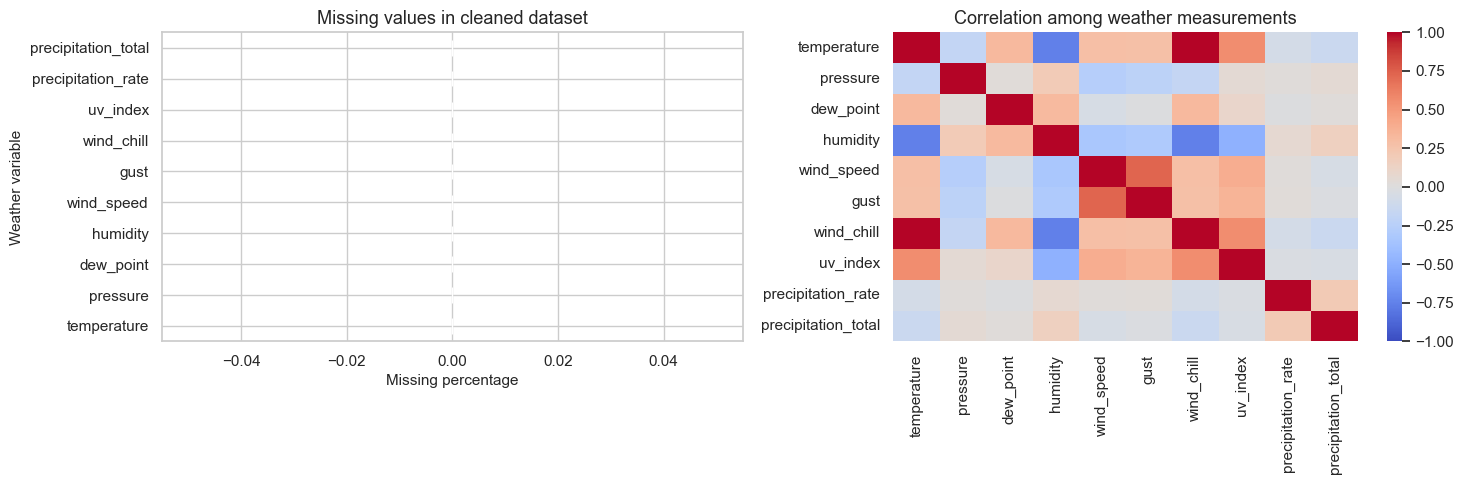

In [8]:
dataset_profile = pd.DataFrame({
    'Metric': [
        'Cleaned rows', 'Columns', 'States', 'Cities', 'Places',
        'Earliest timestamp', 'Latest timestamp', 'Distinct observation dates'
    ],
    'Value': [
        len(analysis_base),
        analysis_base.shape[1],
        analysis_base['state'].nunique(),
        analysis_base['city'].nunique(),
        analysis_base['place'].nunique(),
        analysis_base['datetime'].min(),
        analysis_base['datetime'].max(),
        analysis_base['datetime'].dt.date.nunique(),
    ]
})

display(dataset_profile)

descriptive_stats = analysis_base[weather_cols].describe().T
missing_summary = analysis_base[weather_cols].isna().sum().rename('missing_count').to_frame()
missing_summary['missing_percent'] = missing_summary['missing_count'] / len(analysis_base) * 100

display(descriptive_stats)
display(missing_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
missing_summary.sort_values('missing_percent')['missing_percent'].plot(kind='barh', ax=axes[0])
axes[0].set_title('Missing values in cleaned dataset')
axes[0].set_xlabel('Missing percentage')
axes[0].set_ylabel('Weather variable')

corr = analysis_base[weather_cols].corr(numeric_only=True)
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, center=0)
axes[1].set_title('Correlation among weather measurements')

plt.tight_layout()
plt.show()


## 10. Location Coverage

The client problem is about public weather guidance in Malaysia, so the notebook must check where the observations come from. This section summarises coverage by state, city, and place, then flags how representative the data is for national public communication.


,records,cities,places,first_observation,last_observation,observation_days,rain_event_rate,mean_temperature,record_share,time_span_days
state,,,,,,,,,,
Kuala Lumpur,37160,3,10,2018-01-17 01:00:00,2023-08-30 15:59:42,1813,0.258,28.061,0.719,2051
Pulau Pinang,14533,5,6,2018-01-17 01:00:00,2023-08-30 15:29:54,1869,0.284,28.074,0.281,2051


,state,city,records,first_observation,last_observation,observation_days,rain_event_rate,mean_temperature,record_share,time_span_days
0,Kuala Lumpur,Kuala Lumpur,28201,2019-07-01 00:39:57,2023-08-30 15:59:42,1477,0.257,28.251,0.546,1521
2,Kuala Lumpur,Sepang,7667,2018-01-17 01:00:00,2023-08-30 15:41:00,1406,0.265,27.550,0.148,2051
7,Pulau Pinang,Timur Laut,7611,2019-12-26 17:49:49,2023-08-30 12:54:54,1315,0.311,27.911,0.147,1342
5,Pulau Pinang,George Town,2485,2020-08-13 08:00:51,2023-08-30 15:15:02,852,0.331,28.354,0.048,1112
3,Pulau Pinang,Bayan Lepas,1848,2018-01-17 01:00:00,2023-08-29 12:00:00,1224,0.172,28.604,0.036,2050
4,Pulau Pinang,Bukit Mertajam,1662,2022-11-04 14:59:38,2023-08-30 15:29:54,298,0.275,27.938,0.032,299
1,Kuala Lumpur,Selayang,1292,2022-12-26 17:39:53,2023-08-30 13:29:53,232,0.242,26.928,0.025,246
6,Pulau Pinang,Seberang Perai,927,2018-01-20 11:00:00,2023-08-27 14:00:00,727,0.176,27.853,0.018,2045


,state,city,place,records,first_observation,last_observation,observation_days,rain_event_rate,mean_temperature,record_share,time_span_days
3,Kuala Lumpur,Kuala Lumpur,Bukit Bintang,8459,2019-07-01 00:39:57,2023-08-30 15:59:42,1468,0.151,28.777,0.164,1521
15,Pulau Pinang,Timur Laut,Air Itam,7611,2019-12-26 17:49:49,2023-08-30 12:54:54,1315,0.311,27.911,0.147,1342
4,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,7178,2019-10-28 11:44:54,2023-08-30 13:04:41,1275,0.309,28.889,0.139,1402
5,Kuala Lumpur,Kuala Lumpur,Cheras,3902,2021-09-17 23:54:50,2023-08-30 02:44:51,696,0.312,27.438,0.075,711
0,Kuala Lumpur,Kuala Lumpur,Ampang Jaya,3881,2021-09-17 06:24:56,2023-08-30 14:39:55,675,0.264,27.487,0.075,712
1,Kuala Lumpur,Kuala Lumpur,Bandar Sri Permaisuri,3821,2021-09-17 23:34:50,2023-08-30 14:34:58,693,0.309,27.558,0.074,711
7,Kuala Lumpur,Sepang,Jalan Ayer Hitam,2918,2022-04-04 12:44:54,2023-08-30 13:29:46,507,0.269,27.542,0.056,513
8,Kuala Lumpur,Sepang,Kampung Dato' Abu Bakar Baginda,2851,2022-04-04 08:39:51,2023-08-30 10:54:50,506,0.281,27.393,0.055,513
9,Kuala Lumpur,Sepang,Sepang,1898,2018-01-17 01:00:00,2023-08-30 15:41:00,1213,0.233,27.800,0.037,2051
10,Pulau Pinang,Bayan Lepas,Batu Maung,1848,2018-01-17 01:00:00,2023-08-29 12:00:00,1224,0.172,28.604,0.036,2050


,Question,Answer from data
0,How many states are represented?,"2 states, 8 cities, and 16 places are represen..."
1,Is the record volume balanced by state?,"The largest state share is 71.9%, so the datas..."
2,Can conclusions be treated as national coverage?,No. The findings are useful for the observed K...


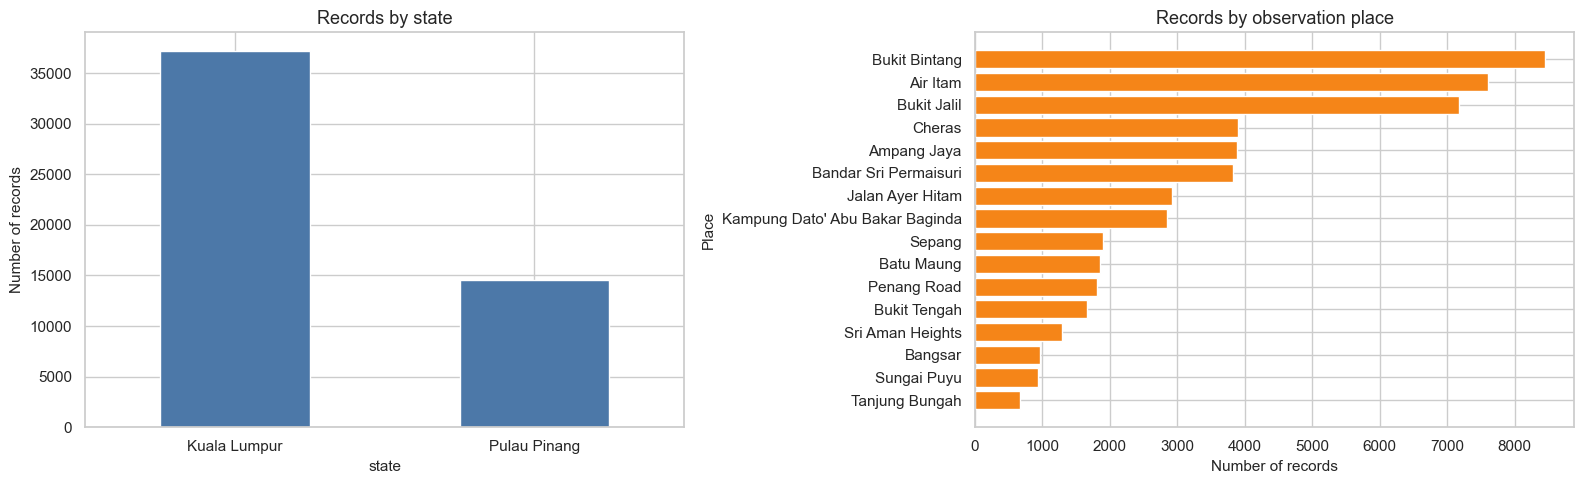

In [9]:
location_audit = analysis_base.copy()
location_audit['rain_event_for_coverage'] = (
    (location_audit['precipitation_rate'] > 0) |
    (location_audit['precipitation_total'] > 0)
).astype(int)

state_coverage = (
    location_audit.groupby('state')
    .agg(
        records=('datetime', 'size'),
        cities=('city', 'nunique'),
        places=('place', 'nunique'),
        first_observation=('datetime', 'min'),
        last_observation=('datetime', 'max'),
        observation_days=('date', 'nunique'),
        rain_event_rate=('rain_event_for_coverage', 'mean'),
        mean_temperature=('temperature', 'mean'),
    )
    .sort_values('records', ascending=False)
)
state_coverage['record_share'] = state_coverage['records'] / len(location_audit)
state_coverage['time_span_days'] = (
    state_coverage['last_observation'] - state_coverage['first_observation']
).dt.days

def build_location_coverage(group_cols):
    """Summarise record volume and time coverage for a location grouping."""
    coverage = (
        location_audit.groupby(group_cols)
        .agg(
            records=('datetime', 'size'),
            first_observation=('datetime', 'min'),
            last_observation=('datetime', 'max'),
            observation_days=('date', 'nunique'),
            rain_event_rate=('rain_event_for_coverage', 'mean'),
            mean_temperature=('temperature', 'mean'),
        )
        .reset_index()
    )
    coverage['record_share'] = coverage['records'] / len(location_audit)
    coverage['time_span_days'] = (coverage['last_observation'] - coverage['first_observation']).dt.days
    return coverage.sort_values('records', ascending=False)

city_coverage = build_location_coverage(['state', 'city'])
place_coverage = build_location_coverage(['state', 'city', 'place'])

coverage_interpretation = pd.DataFrame({
    'Question': [
        'How many states are represented?',
        'Is the record volume balanced by state?',
        'Can conclusions be treated as national coverage?',
    ],
    'Answer from data': [
        f"{analysis_base['state'].nunique()} states, {analysis_base['city'].nunique()} cities, and {analysis_base['place'].nunique()} places are represented.",
        f"The largest state share is {state_coverage['record_share'].max():.1%}, so the dataset is geographically uneven.",
        'No. The findings are useful for the observed Kuala Lumpur and Pulau Pinang locations, but should be validated before being generalised to all Malaysia.',
    ]
})

display(state_coverage)
display(city_coverage)
display(place_coverage.head(16))
display(coverage_interpretation)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
state_coverage['records'].plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Records by state')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=0)

place_plot = place_coverage.sort_values('records', ascending=True)
axes[1].barh(place_plot['place'], place_plot['records'], color='#f58518')
axes[1].set_title('Records by observation place')
axes[1].set_xlabel('Number of records')
axes[1].set_ylabel('Place')

plt.tight_layout()
plt.show()


## 11. Duplicate, Outlier, and Plausibility Checks

Duplicate rows were checked during validation. This section makes the outlier check explicit by combining broad physical/rational bounds from the data dictionary with IQR screening. Extreme weather values are not removed automatically because rare high UV, heavy rain, gusts, or heat conditions can be the most important cases for public communication.


,Variable,Unit,Plausible minimum,Plausible maximum,Reason
0,temperature,degrees C,0,45.000,Broad Malaysian weather screening range
1,pressure,hPa,950,"1,050.000",Broad sea-level pressure screening range
2,dew_point,degrees C,0,35.000,Broad tropical dew point screening range
3,humidity,percent,0,100.000,Relative humidity scale
4,wind_speed,source wind unit,0,NaN,Wind speed cannot be negative
5,gust,source wind unit,0,NaN,Gust cannot be negative
6,wind_chill,degrees C,0,45.000,Broad Malaysian thermal screening range
7,uv_index,UV Index,0,NaN,UV Index cannot be negative; 11+ is extreme
8,precipitation_rate,source precipitation unit,0,NaN,Precipitation cannot be negative
9,precipitation_total,source precipitation unit,0,NaN,Accumulated precipitation cannot be negative


,Variable,Minimum,Q1,Median,Q3,Maximum,IQR lower fence,IQR upper fence,IQR flagged count,IQR flagged percent,Below plausible minimum,Above plausible maximum
0,temperature,17.800,25.700,27.500,30.300,41.000,18.800,37.200,110,0.213,0,0
1,pressure,996.950,"1,006.500","1,010.160","1,013.225","1,023.230",996.412,"1,023.312",0,0.000,0,0
2,dew_point,7.700,23.300,24.100,25.000,32.200,20.750,27.550,3342,6.465,0,0
3,humidity,0.000,72.000,83.000,93.000,100.000,40.500,124.500,85,0.164,0,0
4,wind_speed,0.000,0.000,1.000,3.300,33.800,-4.950,8.250,3429,6.633,0,0
5,gust,0.000,0.000,1.600,4.300,59.000,-6.450,10.750,3072,5.943,0,0
6,wind_chill,17.800,25.700,27.500,30.300,41.000,18.800,37.200,110,0.213,0,0
7,uv_index,0.000,0.000,0.000,2.000,16.000,-3.000,5.000,4923,9.524,0,0
8,precipitation_rate,0.000,0.000,0.000,0.000,432.590,0.000,0.000,2240,4.333,0,0
9,precipitation_total,0.000,0.000,0.000,0.250,162.810,-0.375,0.625,10474,20.262,0,0


,state,city,place,datetime,value,variable
0,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2023-06-19 12:54:41,41.000,temperature
1,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2020-01-01 15:14:59,40.500,temperature
2,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2020-03-11 15:54:50,39.700,temperature
3,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2022-03-23 12:29:59,32.200,dew_point
4,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2021-06-21 15:24:48,32.200,dew_point
5,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2020-10-04 16:14:47,32.200,dew_point
6,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2023-07-11 14:24:56,40.400,humidity
7,Kuala Lumpur,Kuala Lumpur,Bukit Bintang,2019-09-22 12:24:40,40.400,humidity
8,Kuala Lumpur,Kuala Lumpur,Bukit Jalil,2023-05-11 11:39:58,40.300,humidity
9,Pulau Pinang,George Town,Penang Road,2021-12-17 14:30:00,33.800,wind_speed


,Finding,Result / decision
0,Duplicate rows in cleaned final file,0
1,Values outside broad plausibility bounds,0
2,IQR outliers in skewed weather variables,Expected for zero-inflated or event-based vari...
3,Treatment decision,"Retain extreme but plausible values, because h..."


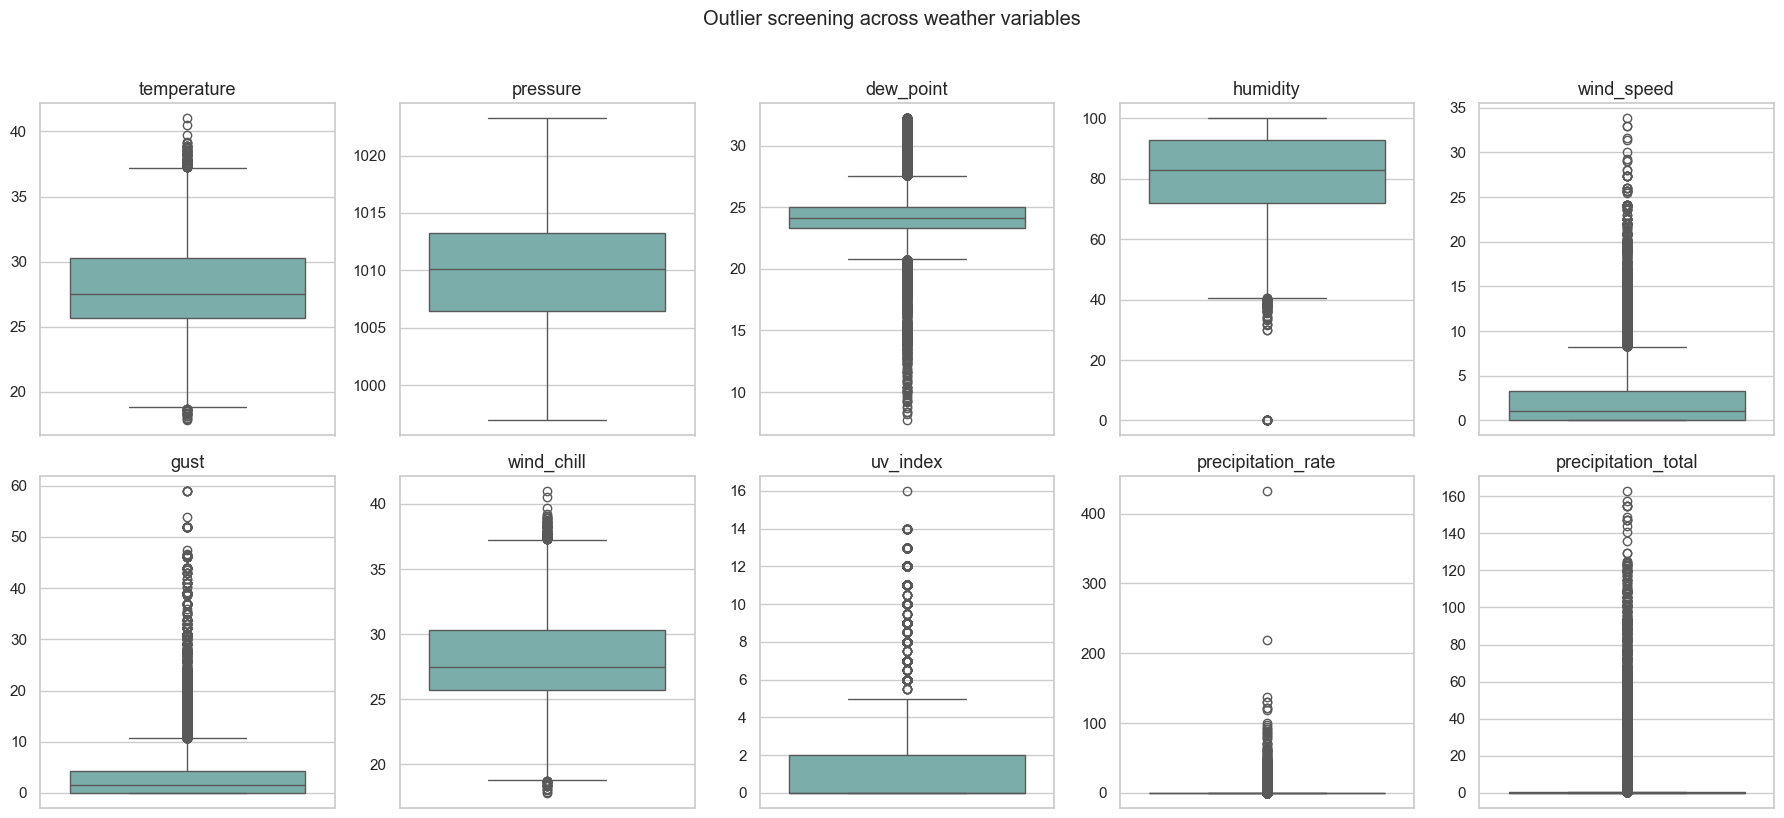

In [10]:
plausibility_rules = pd.DataFrame([
    {'Variable': 'temperature', 'Unit': 'degrees C', 'Plausible minimum': 0, 'Plausible maximum': 45, 'Reason': 'Broad Malaysian weather screening range'},
    {'Variable': 'pressure', 'Unit': 'hPa', 'Plausible minimum': 950, 'Plausible maximum': 1050, 'Reason': 'Broad sea-level pressure screening range'},
    {'Variable': 'dew_point', 'Unit': 'degrees C', 'Plausible minimum': 0, 'Plausible maximum': 35, 'Reason': 'Broad tropical dew point screening range'},
    {'Variable': 'humidity', 'Unit': 'percent', 'Plausible minimum': 0, 'Plausible maximum': 100, 'Reason': 'Relative humidity scale'},
    {'Variable': 'wind_speed', 'Unit': 'source wind unit', 'Plausible minimum': 0, 'Plausible maximum': np.nan, 'Reason': 'Wind speed cannot be negative'},
    {'Variable': 'gust', 'Unit': 'source wind unit', 'Plausible minimum': 0, 'Plausible maximum': np.nan, 'Reason': 'Gust cannot be negative'},
    {'Variable': 'wind_chill', 'Unit': 'degrees C', 'Plausible minimum': 0, 'Plausible maximum': 45, 'Reason': 'Broad Malaysian thermal screening range'},
    {'Variable': 'uv_index', 'Unit': 'UV Index', 'Plausible minimum': 0, 'Plausible maximum': np.nan, 'Reason': 'UV Index cannot be negative; 11+ is extreme'},
    {'Variable': 'precipitation_rate', 'Unit': 'source precipitation unit', 'Plausible minimum': 0, 'Plausible maximum': np.nan, 'Reason': 'Precipitation cannot be negative'},
    {'Variable': 'precipitation_total', 'Unit': 'source precipitation unit', 'Plausible minimum': 0, 'Plausible maximum': np.nan, 'Reason': 'Accumulated precipitation cannot be negative'},
])

outlier_rows = []
for _, rule in plausibility_rules.iterrows():
    col = rule['Variable']
    series = analysis_base[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    plausible_min = rule['Plausible minimum']
    plausible_max = rule['Plausible maximum']
    below_min = int((series < plausible_min).sum()) if pd.notna(plausible_min) else 0
    above_max = int((series > plausible_max).sum()) if pd.notna(plausible_max) else 0
    iqr_mask = (series < lower_iqr) | (series > upper_iqr)
    outlier_rows.append({
        'Variable': col,
        'Minimum': series.min(),
        'Q1': q1,
        'Median': series.median(),
        'Q3': q3,
        'Maximum': series.max(),
        'IQR lower fence': lower_iqr,
        'IQR upper fence': upper_iqr,
        'IQR flagged count': int(iqr_mask.sum()),
        'IQR flagged percent': iqr_mask.mean() * 100,
        'Below plausible minimum': below_min,
        'Above plausible maximum': above_max,
    })

outlier_summary = pd.DataFrame(outlier_rows)
plausibility_issue_count = int(
    outlier_summary['Below plausible minimum'].sum() + outlier_summary['Above plausible maximum'].sum()
)

extreme_examples = []
for _, row in outlier_summary.iterrows():
    col = row['Variable']
    lower_fence = row['IQR lower fence']
    upper_fence = row['IQR upper fence']
    mask = (analysis_base[col] < lower_fence) | (analysis_base[col] > upper_fence)
    examples = (
        analysis_base.loc[mask, ['state', 'city', 'place', 'datetime', col]]
        .rename(columns={col: 'value'})
        .assign(variable=col)
        .sort_values('value', ascending=False)
        .head(3)
    )
    extreme_examples.append(examples)

extreme_examples = pd.concat(extreme_examples, ignore_index=True) if extreme_examples else pd.DataFrame()
outlier_decisions = pd.DataFrame({
    'Finding': [
        'Duplicate rows in cleaned final file',
        'Values outside broad plausibility bounds',
        'IQR outliers in skewed weather variables',
        'Treatment decision',
    ],
    'Result / decision': [
        int(analysis_base.duplicated().sum()),
        plausibility_issue_count,
        'Expected for zero-inflated or event-based variables such as precipitation, gust, wind speed, and UV Index.',
        'Retain extreme but plausible values, because high UV, heavy rain, strong gusts, and hot conditions are important for warnings.',
    ]
})

display(plausibility_rules)
display(outlier_summary)
display(extreme_examples.head(20))
display(outlier_decisions)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, col in zip(axes.ravel(), plausibility_rules['Variable']):
    sns.boxplot(y=analysis_base[col], ax=ax, color='#72b7b2')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
for ax in axes.ravel()[len(plausibility_rules):]:
    ax.axis('off')
plt.suptitle('Outlier screening across weather variables', y=1.02)
plt.tight_layout()
plt.show()


## 12. Data Quality Conclusions from EDA

The cleaned final dataset is suitable for the integrated weather-indicator analysis. It has the expected columns, no duplicate rows, no missing values, valid reconstructed timestamps, and no values outside the broad plausibility bounds used in this notebook.

The main caution is representativeness rather than basic data validity. The observations cover two states, eight cities, and sixteen places, so the results should be described as evidence from the available Kuala Lumpur and Pulau Pinang observations rather than as a complete national weather dataset.

The outlier checks also show why the analysis should not automatically delete extreme values. Variables such as precipitation rate, gust, wind speed, and UV Index are naturally skewed, and rare high values are often exactly the cases a public weather service needs for warning communication.

This EDA leads to four important modelling and communication decisions:

1. Use the cleaned dataset for final analysis, while acknowledging that raw missing values have already been handled in the cleaning stage.
2. Keep extreme but plausible weather values because they can represent meaningful warning conditions.
3. Interpret location-based findings with the dataset's uneven geographic coverage in mind.
4. Interpret correlations and the logistic regression model as evidence of association, not causal proof.


## 13. Modeling / Analysis

### 13.1 Temperature and Wind Chill

This section answers whether wind chill provides additional public communication value beyond temperature in Malaysia.


,Metric,Value
0,Valid rows used,"51,693.000"
1,Mean temperature,28.0646
2,Mean wind chill,28.0616
3,Mean difference: temperature - wind chill,0.0029
4,Median difference,0.0000
5,Correlation,0.9994
6,Rows with exact equality,99.2765%
7,Rows with abs difference <= 0.5 degrees C,99.8143%
8,Rows with abs difference <= 1.0 degrees C,99.9091%
9,Rows with abs difference > 2.0 degrees C,0.0406%


,wind_bin,observations,mean_abs_difference,max_abs_difference
0,0-1,26117,0.003,10.200
1,1-3,11401,0.010,6.100
2,3-5,6182,0.003,4.000
3,5-8,4485,0.001,1.100
4,8+,3508,0.000,0.100


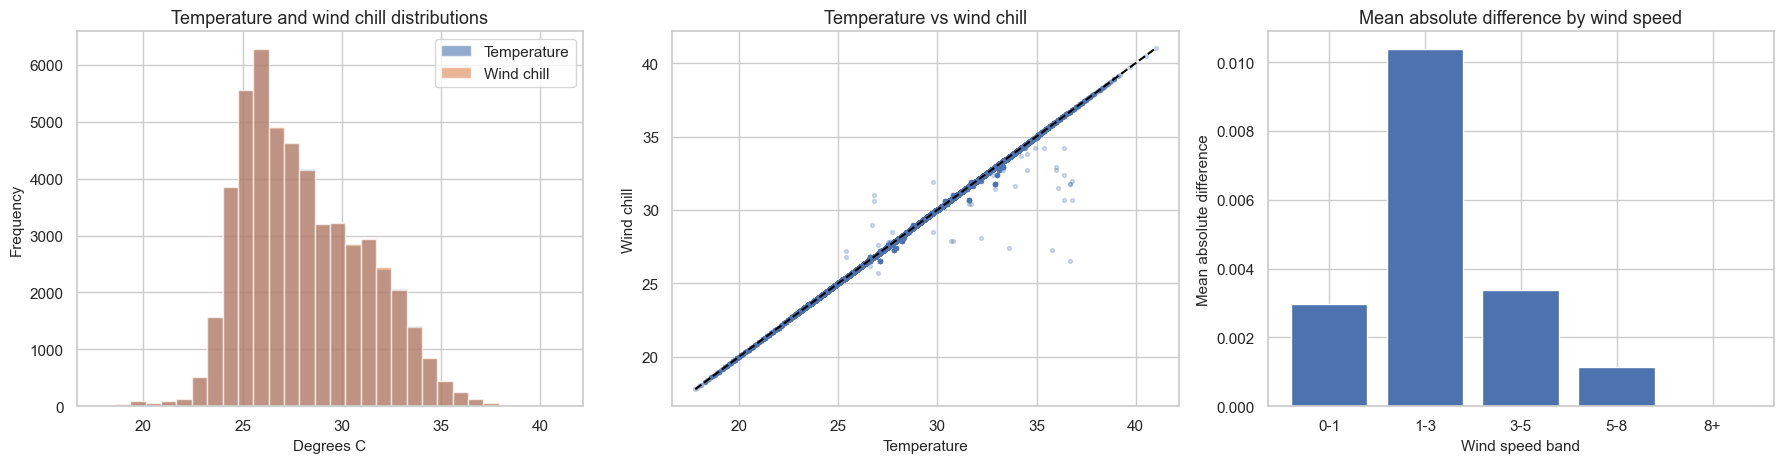

,place,city,state,datetime,temperature,wind_chill,wind_speed,difference,abs_difference,wind_bin
45586,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-24 06:14:59,36.700,26.500,0.400,10.200,10.200,0-1
51472,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-26 04:29:34,35.800,27.300,0.300,8.500,8.500,0-1
32978,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-26 08:59:53,33.600,27.400,0.900,6.200,6.200,0-1
42611,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-22 11:39:33,36.800,30.700,1.700,6.100,6.100,1-3
22960,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-31 11:29:39,36.400,30.700,1.700,5.700,5.700,1-3
11241,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-02-24 14:59:40,36.700,31.800,2.000,4.900,4.900,1-3
15881,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-02-13 14:59:33,36.700,31.800,2.000,4.900,4.900,1-3
14093,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-04-19 11:04:52,36.800,32.000,2.400,4.800,4.800,1-3
18541,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-30 12:04:37,36.100,31.500,0.000,4.600,4.600,0-1
41105,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-04-20 10:34:55,26.800,31.000,1.300,-4.200,4.200,1-3


In [11]:
wind_df = analysis_base[
    ['place', 'city', 'state', 'datetime', 'temperature', 'wind_chill', 'wind_speed']
].dropna(subset=['temperature', 'wind_chill']).copy()
wind_df['difference'] = wind_df['temperature'] - wind_df['wind_chill']
wind_df['abs_difference'] = wind_df['difference'].abs()

wind_metrics = pd.DataFrame({
    'Metric': [
        'Valid rows used',
        'Mean temperature',
        'Mean wind chill',
        'Mean difference: temperature - wind chill',
        'Median difference',
        'Correlation',
        'Rows with exact equality',
        'Rows with abs difference <= 0.5 degrees C',
        'Rows with abs difference <= 1.0 degrees C',
        'Rows with abs difference > 2.0 degrees C',
        'Maximum absolute difference',
        'Rows with non-zero difference',
    ],
    'Value': [
        len(wind_df),
        wind_df['temperature'].mean(),
        wind_df['wind_chill'].mean(),
        wind_df['difference'].mean(),
        wind_df['difference'].median(),
        wind_df['temperature'].corr(wind_df['wind_chill']),
        (wind_df['abs_difference'] == 0).mean(),
        (wind_df['abs_difference'] <= 0.5).mean(),
        (wind_df['abs_difference'] <= 1.0).mean(),
        (wind_df['abs_difference'] > 2.0).mean(),
        wind_df['abs_difference'].max(),
        int((wind_df['abs_difference'] > 0).sum()),
    ]
})

wind_metrics_display = wind_metrics.copy()
percent_rows = [6, 7, 8, 9]
wind_metrics_display['Value'] = wind_metrics_display['Value'].astype(object)
for idx in percent_rows:
    wind_metrics_display.loc[idx, 'Value'] = f"{wind_metrics.loc[idx, 'Value'] * 100:.4f}%"
for idx in [1, 2, 3, 4, 5, 10]:
    wind_metrics_display.loc[idx, 'Value'] = f"{wind_metrics.loc[idx, 'Value']:.4f}"

display(wind_metrics_display)

wind_df['wind_bin'] = pd.cut(
    wind_df['wind_speed'],
    bins=[-0.01, 1, 3, 5, 8, np.inf],
    labels=['0-1', '1-3', '3-5', '5-8', '8+']
)
wind_summary = (
    wind_df.dropna(subset=['wind_bin'])
    .groupby('wind_bin', observed=False)['abs_difference']
    .agg(observations='size', mean_abs_difference='mean', max_abs_difference='max')
    .reset_index()
)
display(wind_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
axes[0].hist(wind_df['temperature'], bins=30, alpha=0.6, label='Temperature')
axes[0].hist(wind_df['wind_chill'], bins=30, alpha=0.6, label='Wind chill')
axes[0].set_title('Temperature and wind chill distributions')
axes[0].set_xlabel('Degrees C')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].scatter(wind_df['temperature'], wind_df['wind_chill'], s=8, alpha=0.25)
min_val = min(wind_df['temperature'].min(), wind_df['wind_chill'].min())
max_val = max(wind_df['temperature'].max(), wind_df['wind_chill'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')
axes[1].set_title('Temperature vs wind chill')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Wind chill')

axes[2].bar(wind_summary['wind_bin'].astype(str), wind_summary['mean_abs_difference'])
axes[2].set_title('Mean absolute difference by wind speed')
axes[2].set_xlabel('Wind speed band')
axes[2].set_ylabel('Mean absolute difference')

plt.tight_layout()
plt.show()

non_zero_wind = wind_df.loc[wind_df['abs_difference'] > 0].sort_values('abs_difference', ascending=False)
display(non_zero_wind.head(10))


**Temperature and wind chill conclusion:** The two variables are practically identical in the observed data. Wind chill has near-perfect correlation with temperature, and almost every valid record has exactly the same value for both variables. For a Malaysian public weather service, wind chill should not be a headline thermal indicator. Temperature should be shown instead, while warm-weather comfort should be explained using humidity, dew point, or heat-index-style measures.


### 13.2 Humidity, Dew Point, and Oppressive Weather

This section compares humidity and dew point as indicators of muggy or oppressive weather.


,count,mean,std,min,25%,50%,75%,max
temperature,"51,693.000",28.065,3.076,17.800,25.700,27.500,30.300,41.000
humidity,"51,693.000",81.344,13.448,0.000,72.000,83.000,93.000,100.000
dew_point,"51,693.000",24.259,1.887,7.700,23.300,24.100,25.000,32.200


,Metric,Value
0,Valid rows used,"51,693.000"
1,Mean humidity,81.344
2,Mean dew point,24.259
3,Pearson correlation: humidity vs dew point,0.315
4,Spearman correlation: humidity vs dew point,0.268
5,Share with humidity >= 80%,57.48%
6,Share with dew point >= 24 degrees C,57.08%
7,Share meeting both thresholds,36.10%


,heat_index,humidity,dew_point,temperature
heat_index,1.000,-0.027,0.562,0.769
humidity,-0.027,1.000,0.651,-0.625
dew_point,0.562,0.651,1.000,0.100
temperature,0.769,-0.625,0.100,1.000


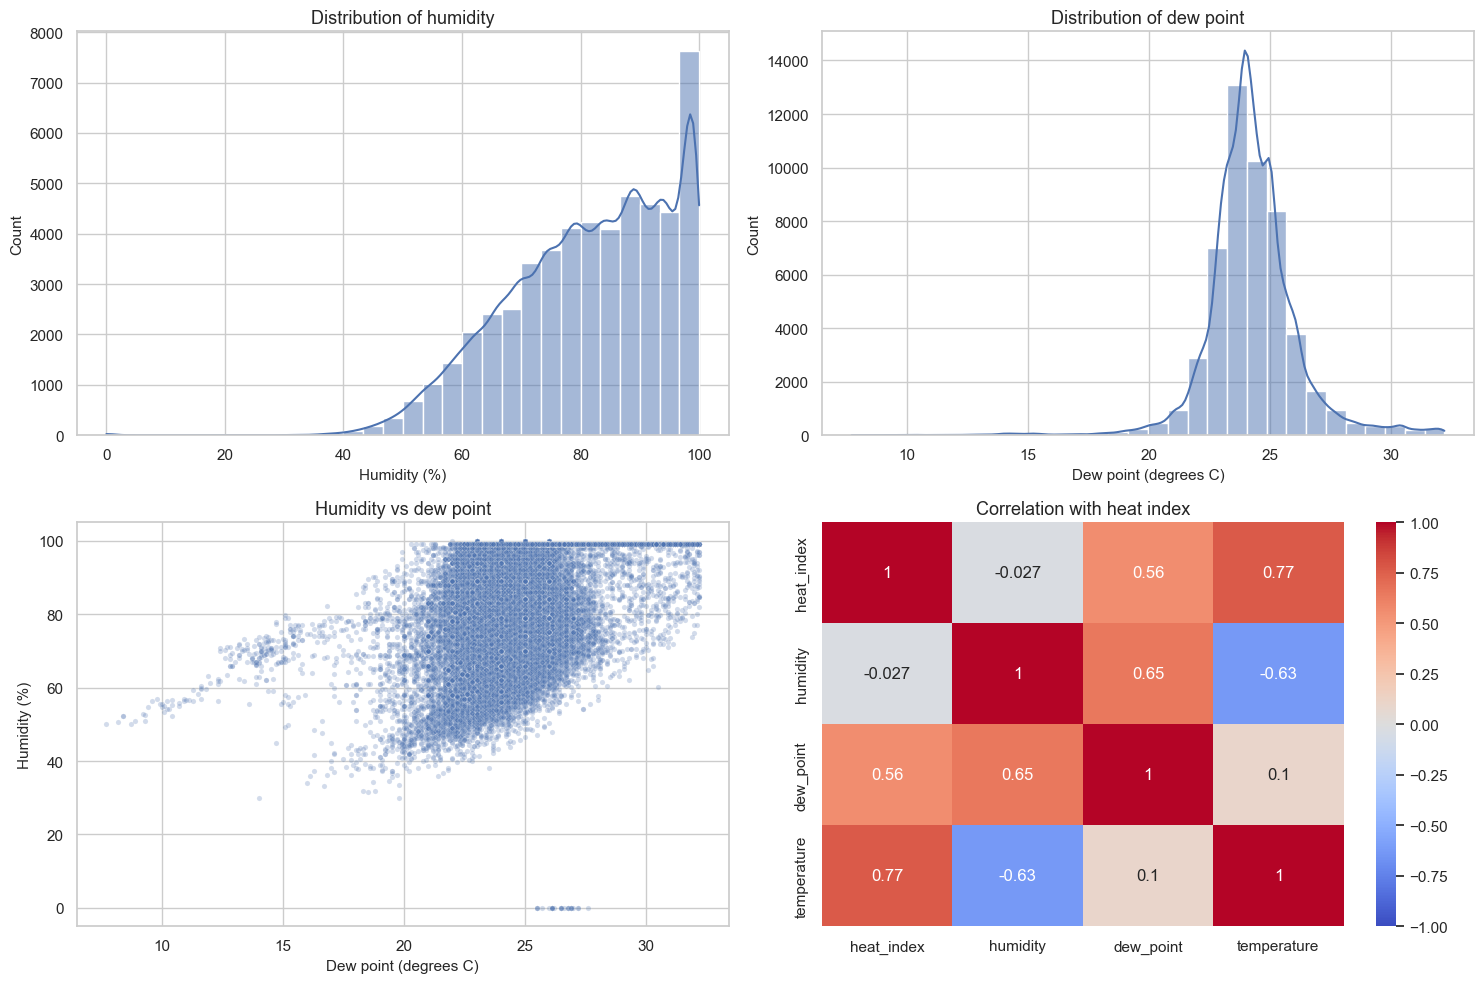

,records,mean_temperature,mean_humidity,mean_dew_point,oppressive_dew_point_rate
state,,,,,
Pulau Pinang,14533,28.074,81.694,24.461,0.702
Kuala Lumpur,37160,28.061,81.207,24.181,0.519


In [12]:
humidity_df = analysis_base[
    ['datetime', 'city', 'state', 'temperature', 'humidity', 'dew_point']
].dropna(subset=['temperature', 'humidity', 'dew_point']).copy()
humidity_df['heat_index'] = add_heat_index(humidity_df)
humidity_df['oppressive_dew_point'] = humidity_df['dew_point'] >= 24
humidity_df['high_humidity'] = humidity_df['humidity'] >= 80

humidity_summary = humidity_df[['temperature', 'humidity', 'dew_point']].describe().T

dew_humidity_metrics = pd.DataFrame({
    'Metric': [
        'Valid rows used',
        'Mean humidity',
        'Mean dew point',
        'Pearson correlation: humidity vs dew point',
        'Spearman correlation: humidity vs dew point',
        'Share with humidity >= 80%',
        'Share with dew point >= 24 degrees C',
        'Share meeting both thresholds',
    ],
    'Value': [
        len(humidity_df),
        humidity_df['humidity'].mean(),
        humidity_df['dew_point'].mean(),
        humidity_df['humidity'].corr(humidity_df['dew_point']),
        humidity_df['humidity'].corr(humidity_df['dew_point'], method='spearman'),
        humidity_df['high_humidity'].mean(),
        humidity_df['oppressive_dew_point'].mean(),
        (humidity_df['high_humidity'] & humidity_df['oppressive_dew_point']).mean(),
    ]
})

dew_humidity_display = dew_humidity_metrics.copy()
dew_humidity_display['Value'] = dew_humidity_display['Value'].astype(object)
for idx in [5, 6, 7]:
    dew_humidity_display.loc[idx, 'Value'] = f"{dew_humidity_metrics.loc[idx, 'Value'] * 100:.2f}%"
for idx in [1, 2, 3, 4]:
    dew_humidity_display.loc[idx, 'Value'] = f"{dew_humidity_metrics.loc[idx, 'Value']:.3f}"

display(humidity_summary)
display(dew_humidity_display)

warm_weather = humidity_df[(humidity_df['temperature'] >= 27) & (humidity_df['humidity'] >= 40)].copy()
heat_index_corr = warm_weather[['heat_index', 'humidity', 'dew_point', 'temperature']].corr()
display(heat_index_corr)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(humidity_df['humidity'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of humidity')
axes[0, 0].set_xlabel('Humidity (%)')

sns.histplot(humidity_df['dew_point'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of dew point')
axes[0, 1].set_xlabel('Dew point (degrees C)')

sns.scatterplot(data=humidity_df, x='dew_point', y='humidity', alpha=0.25, s=14, ax=axes[1, 0])
axes[1, 0].set_title('Humidity vs dew point')
axes[1, 0].set_xlabel('Dew point (degrees C)')
axes[1, 0].set_ylabel('Humidity (%)')

sns.heatmap(heat_index_corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation with heat index')

plt.tight_layout()
plt.show()

state_comfort_summary = (
    humidity_df.groupby('state')
    .agg(
        records=('humidity', 'size'),
        mean_temperature=('temperature', 'mean'),
        mean_humidity=('humidity', 'mean'),
        mean_dew_point=('dew_point', 'mean'),
        oppressive_dew_point_rate=('oppressive_dew_point', 'mean'),
    )
    .sort_values('mean_dew_point', ascending=False)
)
display(state_comfort_summary)


**Humidity and dew point conclusion:** Humidity and dew point are related, but not interchangeable. Relative humidity is strongly shaped by temperature, while dew point more directly reflects moisture in the air. A dew point threshold around 24 degrees C identifies many observations as muggy or oppressive, and dew point has a stronger positive relationship with heat index than humidity alone. For public messaging, dew point is the better single moisture indicator, while humidity remains useful supporting context.


### 13.3 Pressure, Pressure Trend, and Rainfall

This section improves the pressure analysis by calculating pressure change within each location and by separating current rainfall from **next-observation rainfall**. This better matches the question of whether falling pressure can support early rainfall guidance.


,count,mean,std,min,25%,50%,75%,max
pressure,"51,661.000","1,009.955",4.420,996.950,"1,006.496","1,010.160","1,013.225","1,023.230"
pressure_change_1obs,"51,661.000",-0.000,1.680,-6.775,-1.000,0.000,1.010,7.150
pressure_change_3obs,"51,629.000",-0.000,2.050,-10.000,-1.405,0.000,1.440,8.980
precipitation_rate,"51,661.000",0.310,3.792,0.000,0.000,0.000,0.000,432.590


,records,current_rain_rate,next_observation_rain_rate,mean_pressure,mean_pressure_change
pressure_trend,,,,,
Falling,23558,24.75%,27.57%,"1,009.393",-1.388
Stable/Rising,28103,28.00%,25.67%,"1,010.426",1.163


,precipitation_rate,rain_event,next_rain_event
pressure,0.018,0.068,0.063
pressure_change_1obs,0.001,0.013,-0.036
pressure_change_3obs,-0.006,-0.030,-0.035
temperature,-0.071,-0.146,-0.063
humidity,0.070,0.206,0.133
wind_speed,0.019,-0.013,0.006
precipitation_rate,1.000,0.136,0.111
rain_event,0.136,1.000,0.626
next_rain_event,0.111,0.626,1.000


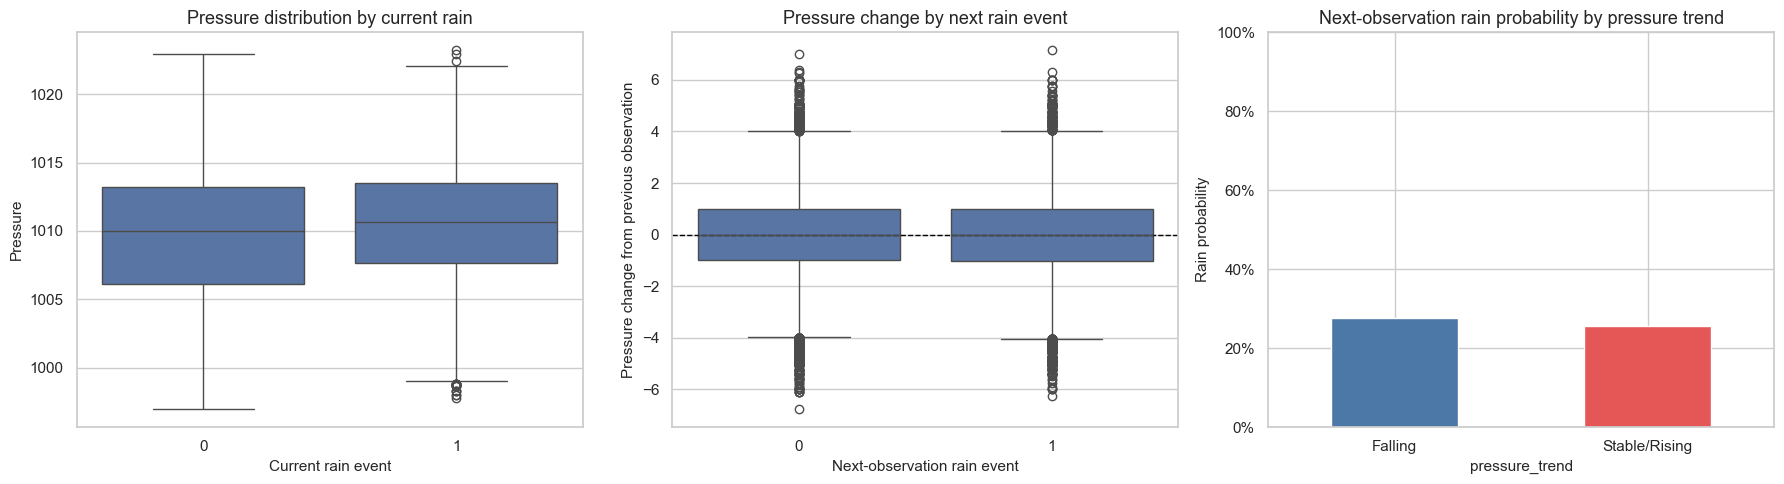

In [13]:
pressure_df = analysis_base.dropna(
    subset=['pressure', 'precipitation_rate', 'temperature', 'humidity', 'dew_point', 'wind_speed']
).copy()
pressure_df = pressure_df.sort_values(pressure_sort_cols).reset_index(drop=True)
pressure_df['rain_event'] = (
    (pressure_df['precipitation_rate'] > 0) |
    (pressure_df['precipitation_total'].fillna(0) > 0)
).astype(int)
pressure_df['pressure_change_1obs'] = pressure_df.groupby(location_cols)['pressure'].diff()
pressure_df['pressure_change_3obs'] = pressure_df.groupby(location_cols)['pressure'].diff(3)
pressure_df['next_rain_event'] = pressure_df.groupby(location_cols)['rain_event'].shift(-1)
pressure_df['pressure_trend'] = np.where(pressure_df['pressure_change_1obs'] < 0, 'Falling', 'Stable/Rising')

pressure_analysis_df = pressure_df.dropna(subset=['pressure_change_1obs', 'next_rain_event']).copy()
pressure_analysis_df['next_rain_event'] = pressure_analysis_df['next_rain_event'].astype(int)

pressure_stats = pressure_analysis_df[
    ['pressure', 'pressure_change_1obs', 'pressure_change_3obs', 'precipitation_rate']
].describe().T

trend_summary = (
    pressure_analysis_df.groupby('pressure_trend')
    .agg(
        records=('rain_event', 'size'),
        current_rain_rate=('rain_event', 'mean'),
        next_observation_rain_rate=('next_rain_event', 'mean'),
        mean_pressure=('pressure', 'mean'),
        mean_pressure_change=('pressure_change_1obs', 'mean'),
    )
)
trend_display = trend_summary.copy()
for col in ['current_rain_rate', 'next_observation_rain_rate']:
    trend_display[col] = trend_display[col].map(lambda x: f'{x:.2%}')

display(pressure_stats)
display(trend_display)

pressure_corr = pressure_analysis_df[[
    'pressure', 'pressure_change_1obs', 'pressure_change_3obs',
    'temperature', 'humidity', 'wind_speed', 'precipitation_rate',
    'rain_event', 'next_rain_event'
]].corr(numeric_only=True)
display(pressure_corr[['precipitation_rate', 'rain_event', 'next_rain_event']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=pressure_analysis_df, x='rain_event', y='pressure', ax=axes[0])
axes[0].set_title('Pressure distribution by current rain')
axes[0].set_xlabel('Current rain event')
axes[0].set_ylabel('Pressure')

sns.boxplot(data=pressure_analysis_df, x='next_rain_event', y='pressure_change_1obs', ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Pressure change by next rain event')
axes[1].set_xlabel('Next-observation rain event')
axes[1].set_ylabel('Pressure change from previous observation')

trend_summary['next_observation_rain_rate'].plot(kind='bar', ax=axes[2], color=['#4c78a8', '#e45756'])
axes[2].set_title('Next-observation rain probability by pressure trend')
axes[2].set_ylabel('Rain probability')
axes[2].set_ylim(0, 1)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [14]:
model_results = None
feature_importance = None

if SKLEARN_AVAILABLE:
    model_features = [
        'pressure', 'pressure_change_1obs', 'pressure_change_3obs',
        'temperature', 'humidity', 'dew_point', 'wind_speed',
        'falling_pressure', 'hour_sin', 'hour_cos'
    ]
    rain_model_df = model_ready.dropna(subset=model_features + ['next_rain_event']).copy()
    rain_model_df['next_rain_event'] = rain_model_df['next_rain_event'].astype(int)

    X = rain_model_df[model_features]
    y = rain_model_df['next_rain_event']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    rain_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced')
    )
    rain_model.fit(X_train, y_train)

    y_probability = rain_model.predict_proba(X_test)[:, 1]
    y_pred = (y_probability >= 0.50).astype(int)
    baseline_pred = np.zeros_like(y_test)

    model_results = pd.DataFrame({
        'Metric': [
            'Test rows', 'Positive class rate in test set',
            'Model accuracy', 'Model precision', 'Model recall', 'Model F1',
            'Model ROC-AUC', 'Model average precision',
            'No-rain baseline accuracy', 'No-rain baseline recall'
        ],
        'Value': [
            len(y_test),
            y_test.mean(),
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, y_probability),
            average_precision_score(y_test, y_probability),
            accuracy_score(y_test, baseline_pred),
            recall_score(y_test, baseline_pred, zero_division=0),
        ]
    })

    display(model_results)

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=['Actual no next rain', 'Actual next rain'],
        columns=['Predicted no next rain', 'Predicted next rain']
    )
    display(cm)

    logistic_model = rain_model.named_steps['logisticregression']
    feature_importance = (
        pd.Series(logistic_model.coef_[0], index=model_features, name='standardised_logistic_coefficient')
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .to_frame()
    )
    display(feature_importance)
else:
    print('scikit-learn is not installed, so the rainfall model was skipped.')


,Metric,Value
0,Test rows,"12,908.000"
1,Positive class rate in test set,0.265
2,Model accuracy,0.649
3,Model precision,0.397
4,Model recall,0.621
5,Model F1,0.484
6,Model ROC-AUC,0.691
7,Model average precision,0.441
8,No-rain baseline accuracy,0.735
9,No-rain baseline recall,0.000


,Predicted no next rain,Predicted next rain
Actual no next rain,6251,3232
Actual next rain,1299,2126


,standardised_logistic_coefficient
hour_cos,-0.597
hour_sin,-0.399
humidity,0.383
temperature,-0.366
dew_point,0.160
pressure,0.114
pressure_change_1obs,-0.069
wind_speed,0.059
falling_pressure,0.033
pressure_change_3obs,0.005


**Pressure and rainfall conclusion:** Pressure has a relationship with rainfall, but the pattern is modest rather than strong. Falling pressure is more useful for thinking about the next observation than the current observation, which fits the idea of pressure trend as an early signal. However, the predictive model shows that pressure trend should be combined with humidity, temperature, wind, and time features. It should be communicated as a supporting rainfall-risk indicator, not as a standalone forecast.


### 13.4 UV Index Conditions and Warning Thresholds

The cleaned final dataset contains no missing UV Index values. Because the raw file did contain missing UV values, this section treats `uv_index = 0` as a cleaned final value and avoids claiming that every zero must have been directly observed. Public warning thresholds are interpreted using valid cleaned UV values and standard UV categories.


,Metric,Value
0,Rows with valid UV Index,"51,693.000"
1,Rows with missing UV Index,0.000
2,Rows where UV Index = 0,"33,777.000"
3,Rows where UV Index > 0,"17,916.000"
4,Rows where UV Index >= 6,"4,918.000"
5,Rows where UV Index >= 8,"2,235.000"
6,Maximum UV Index,16.000


,uv_category,records,average_uv,median_uv,daylight_records,share_of_valid_uv_records,share_of_daylight_uv_records
0,Low (0-2),40854,0.249,0.000,7077,79.0%,39.5%
1,Moderate (3-5),5916,3.824,4.000,5916,11.4%,33.0%
2,High (6-7),2682,6.491,6.000,2682,5.2%,15.0%
3,Very high (8-10),1724,8.722,9.000,1724,3.3%,9.6%
4,Extreme (11+),517,11.685,11.000,517,1.0%,2.9%


,hour,records,mean_uv,median_uv,max_uv,warning_rate_ge6,very_high_rate_ge8
10,10,2142,3.337,3.000,11.000,0.171,0.023
11,11,2129,4.634,5.000,13.000,0.413,0.170
12,12,2209,5.046,5.000,14.000,0.468,0.249
13,13,2161,5.077,5.000,16.000,0.441,0.257
14,14,2165,4.278,4.000,14.000,0.370,0.196
15,15,2162,3.335,3.000,12.000,0.235,0.092
16,16,2117,2.031,1.000,8.000,0.045,0.002


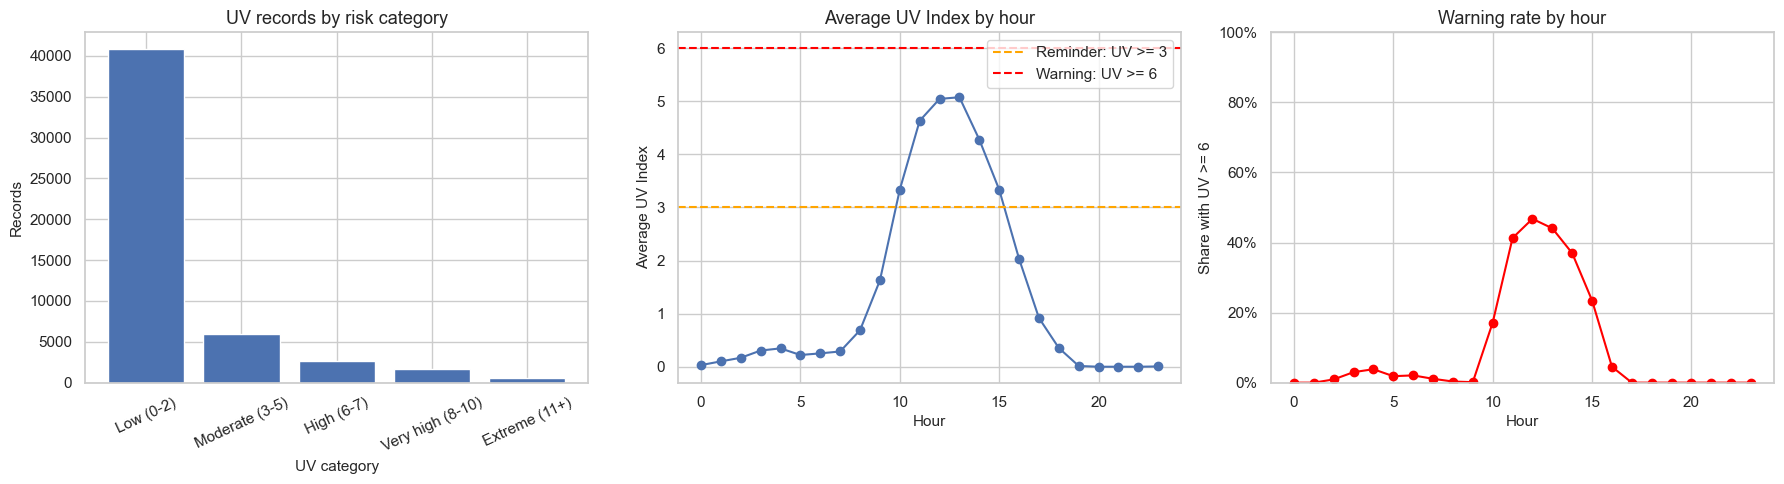

In [15]:
uv_df = analysis_base.dropna(subset=['uv_index']).copy()
uv_bins = [-0.1, 2, 5, 7, 10, np.inf]
uv_labels = ['Low (0-2)', 'Moderate (3-5)', 'High (6-7)', 'Very high (8-10)', 'Extreme (11+)']
uv_df['uv_category'] = pd.cut(uv_df['uv_index'], bins=uv_bins, labels=uv_labels)
uv_df['daylight_uv'] = uv_df['uv_index'] > 0
uv_df['sun_protection_needed'] = uv_df['uv_index'] >= 3
uv_df['public_warning'] = uv_df['uv_index'] >= 6
uv_df['very_high_alert'] = uv_df['uv_index'] >= 8
uv_df['extreme_alert'] = uv_df['uv_index'] >= 11
uv_df['wet_weather'] = uv_df['precipitation_rate'].fillna(0) > 0

uv_cleaning_summary = pd.DataFrame({
    'Metric': [
        'Rows with valid UV Index',
        'Rows with missing UV Index',
        'Rows where UV Index = 0',
        'Rows where UV Index > 0',
        'Rows where UV Index >= 6',
        'Rows where UV Index >= 8',
        'Maximum UV Index',
    ],
    'Value': [
        len(uv_df),
        int(analysis_base['uv_index'].isna().sum()),
        int((uv_df['uv_index'] == 0).sum()),
        int(uv_df['daylight_uv'].sum()),
        int(uv_df['public_warning'].sum()),
        int(uv_df['very_high_alert'].sum()),
        uv_df['uv_index'].max(),
    ]
})

display(uv_cleaning_summary)

category_summary = (
    uv_df.groupby('uv_category', observed=False)
    .agg(
        records=('uv_index', 'size'),
        average_uv=('uv_index', 'mean'),
        median_uv=('uv_index', 'median')
    )
    .reset_index()
)
daylight_counts = (
    uv_df.loc[uv_df['daylight_uv']]
    .groupby('uv_category', observed=False)
    .size()
    .reindex(category_summary['uv_category'])
    .fillna(0)
    .astype(int)
    .to_numpy()
)
category_summary['daylight_records'] = daylight_counts
category_summary['share_of_valid_uv_records'] = category_summary['records'] / len(uv_df)
category_summary['share_of_daylight_uv_records'] = category_summary['daylight_records'] / uv_df['daylight_uv'].sum()

category_display = category_summary.copy()
for col in ['share_of_valid_uv_records', 'share_of_daylight_uv_records']:
    category_display[col] = category_display[col].map(lambda x: f'{x:.1%}')
display(category_display)

hour_summary = (
    uv_df.groupby('hour')
    .agg(
        records=('uv_index', 'size'),
        mean_uv=('uv_index', 'mean'),
        median_uv=('uv_index', 'median'),
        max_uv=('uv_index', 'max'),
        warning_rate_ge6=('public_warning', 'mean'),
        very_high_rate_ge8=('very_high_alert', 'mean')
    )
    .reset_index()
)
main_warning_window = hour_summary[hour_summary['hour'].between(10, 16)].copy()
display(main_warning_window)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(category_summary['uv_category'].astype(str), category_summary['records'])
axes[0].set_title('UV records by risk category')
axes[0].set_xlabel('UV category')
axes[0].set_ylabel('Records')
axes[0].tick_params(axis='x', rotation=25)

axes[1].plot(hour_summary['hour'], hour_summary['mean_uv'], marker='o')
axes[1].axhline(3, linestyle='--', color='orange', label='Reminder: UV >= 3')
axes[1].axhline(6, linestyle='--', color='red', label='Warning: UV >= 6')
axes[1].set_title('Average UV Index by hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average UV Index')
axes[1].legend()

axes[2].plot(hour_summary['hour'], hour_summary['warning_rate_ge6'], marker='o', color='red')
axes[2].set_title('Warning rate by hour')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Share with UV >= 6')
axes[2].set_ylim(0, 1)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()


,uv_category,records,median_uv,mean_temperature,median_temperature,mean_humidity,median_humidity,mean_dew_point,median_pressure,median_wind_speed,wet_weather_rate,median_hour
0,Low (0-2),40854,0.000,27.207,26.800,84.541,86.800,24.158,"1,010.160",0.500,5.1%,10.000
1,Moderate (3-5),5916,4.000,30.925,31.000,72.005,71.150,24.818,"1,009.990",2.800,2.1%,12.000
2,High (6-7),2682,6.000,31.725,31.900,66.143,66.000,24.410,"1,011.680",3.400,0.5%,12.000
3,Very high (8-10),1724,9.000,31.689,32.000,65.916,66.000,24.380,"1,011.010",4.600,0.6%,12.000
4,Extreme (11+),517,11.000,32.044,32.000,65.915,66.000,24.741,"1,009.820",7.000,0.8%,13.000


,correlation_with_uv_index
humidity,-0.489
precipitation_total,-0.042
precipitation_rate,-0.026
month_number,-0.022
pressure,0.049
hour,0.054
dew_point,0.097
gust,0.354
wind_speed,0.392
temperature,0.559


,threshold,category_level,records,share_of_valid_uv_records,share_of_daylight_uv_records,share_occurring_between_10_and_16,recommended_client_action
0,UV Index >= 3,Moderate or above,10741,20.8%,60.0%,87.2%,Show sun-protection reminder
1,UV Index >= 6,High or above,4918,9.5%,27.5%,94.2%,Issue public UV warning
2,UV Index >= 8,Very high or above,2235,4.3%,12.5%,95.8%,Escalate warning / extra protection
3,UV Index >= 11,Extreme,511,1.0%,2.9%,95.5%,Urgent extreme UV alert


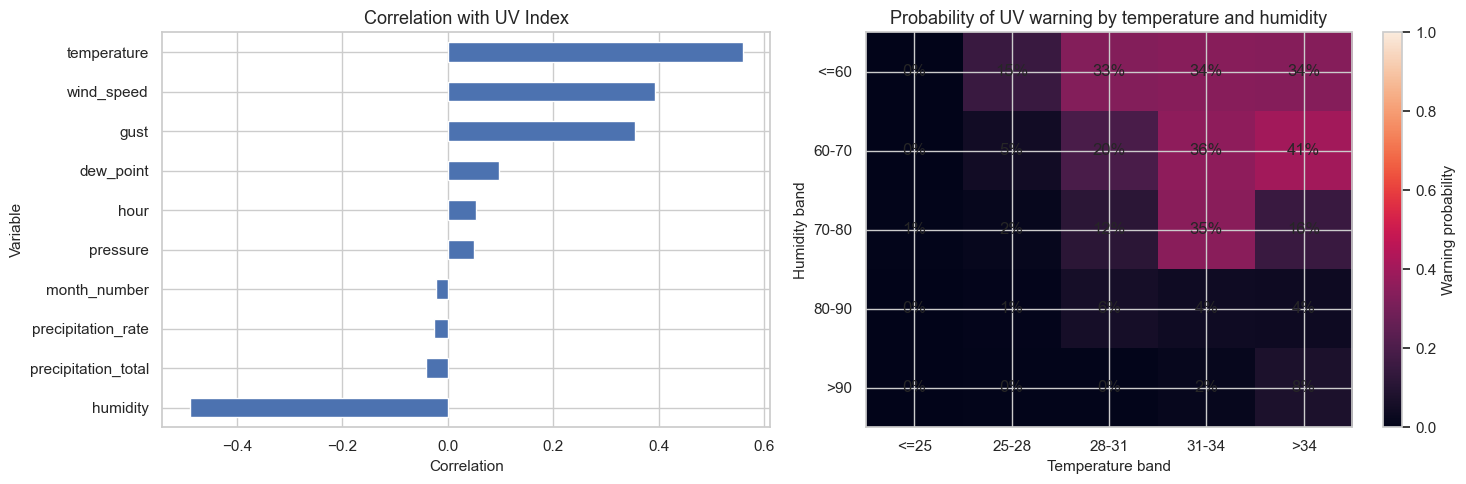

In [16]:
condition_summary = (
    uv_df.groupby('uv_category', observed=False)
    .agg(
        records=('uv_index', 'size'),
        median_uv=('uv_index', 'median'),
        mean_temperature=('temperature', 'mean'),
        median_temperature=('temperature', 'median'),
        mean_humidity=('humidity', 'mean'),
        median_humidity=('humidity', 'median'),
        mean_dew_point=('dew_point', 'mean'),
        median_pressure=('pressure', 'median'),
        median_wind_speed=('wind_speed', 'median'),
        wet_weather_rate=('wet_weather', 'mean'),
        median_hour=('hour', 'median'),
    )
    .reset_index()
)
condition_display = condition_summary.copy()
condition_display['wet_weather_rate'] = condition_display['wet_weather_rate'].map(lambda x: f'{x:.1%}')
display(condition_display)

corr_vars = [
    'uv_index', 'temperature', 'humidity', 'dew_point', 'pressure', 'wind_speed',
    'gust', 'precipitation_rate', 'precipitation_total', 'hour', 'month_number'
]
correlation_with_uv = (
    uv_df[corr_vars]
    .corr(numeric_only=True)['uv_index']
    .drop('uv_index')
    .sort_values()
)
display(correlation_with_uv.to_frame('correlation_with_uv_index'))

uv_df['temperature_bin'] = pd.cut(
    uv_df['temperature'],
    bins=[-np.inf, 25, 28, 31, 34, np.inf],
    labels=['<=25', '25-28', '28-31', '31-34', '>34']
)
uv_df['humidity_bin'] = pd.cut(
    uv_df['humidity'],
    bins=[-np.inf, 60, 70, 80, 90, np.inf],
    labels=['<=60', '60-70', '70-80', '80-90', '>90']
)
risk_grid = (
    uv_df.dropna(subset=['temperature_bin', 'humidity_bin'])
    .groupby(['humidity_bin', 'temperature_bin'], observed=False)['public_warning']
    .mean()
    .unstack()
)

threshold_rows = []
for threshold, label, client_action in [
    (3, 'Moderate or above', 'Show sun-protection reminder'),
    (6, 'High or above', 'Issue public UV warning'),
    (8, 'Very high or above', 'Escalate warning / extra protection'),
    (11, 'Extreme', 'Urgent extreme UV alert'),
]:
    mask = uv_df['uv_index'] >= threshold
    threshold_rows.append({
        'threshold': f'UV Index >= {threshold}',
        'category_level': label,
        'records': int(mask.sum()),
        'share_of_valid_uv_records': mask.mean(),
        'share_of_daylight_uv_records': mask.sum() / uv_df['daylight_uv'].sum(),
        'share_occurring_between_10_and_16': uv_df.loc[mask, 'hour'].between(10, 16).mean(),
        'recommended_client_action': client_action,
    })
threshold_summary = pd.DataFrame(threshold_rows)
threshold_display = threshold_summary.copy()
for col in ['share_of_valid_uv_records', 'share_of_daylight_uv_records', 'share_occurring_between_10_and_16']:
    threshold_display[col] = threshold_display[col].map(lambda x: f'{x:.1%}')
display(threshold_display)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
correlation_with_uv.plot(kind='barh', ax=axes[0])
axes[0].set_title('Correlation with UV Index')
axes[0].set_xlabel('Correlation')
axes[0].set_ylabel('Variable')

image = axes[1].imshow(risk_grid, aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Probability of UV warning by temperature and humidity')
axes[1].set_xlabel('Temperature band')
axes[1].set_ylabel('Humidity band')
axes[1].set_xticks(range(len(risk_grid.columns)))
axes[1].set_yticks(range(len(risk_grid.index)))
axes[1].set_xticklabels(risk_grid.columns)
axes[1].set_yticklabels(risk_grid.index)
for row in range(risk_grid.shape[0]):
    for col in range(risk_grid.shape[1]):
        value = risk_grid.iloc[row, col]
        if pd.notna(value):
            axes[1].text(col, row, f'{value:.0%}', ha='center', va='center')
fig.colorbar(image, ax=axes[1], label='Warning probability')

plt.tight_layout()
plt.show()


**UV Index conclusion:** The highest UV values are mainly associated with late morning to mid-afternoon conditions, warmer temperatures, lower relative humidity than low-UV periods, and little current rain. These variables describe the context around high UV, but they do not replace direct UV Index reporting. The recommended public warning threshold is **UV Index >= 6**, with a general reminder at **UV Index >= 3** and stronger alerts at **UV Index >= 8**.


## 14. Client Recommendations from the Analysis

The table below turns the statistical results into client-facing recommendations for a Malaysian public weather information service.


In [17]:
pressure_next_falling = trend_summary.loc['Falling', 'next_observation_rain_rate'] if 'Falling' in trend_summary.index else np.nan
pressure_next_stable = trend_summary.loc['Stable/Rising', 'next_observation_rain_rate'] if 'Stable/Rising' in trend_summary.index else np.nan
rain_auc = None
if model_results is not None:
    rain_auc = float(model_results.loc[model_results['Metric'] == 'Model ROC-AUC', 'Value'].iloc[0])

recommendations = pd.DataFrame({
    'Indicator': ['Temperature', 'Wind chill', 'Dew point', 'Humidity', 'Pressure trend', 'UV Index'],
    'Evidence from analysis': [
        f"Mean temperature is {wind_df['temperature'].mean():.2f} degrees C in the wind-chill comparison sample.",
        f"{(wind_df['abs_difference'] == 0).mean() * 100:.2f}% of valid temperature/wind-chill records are exactly equal.",
        f"{humidity_df['oppressive_dew_point'].mean() * 100:.2f}% of valid records have dew point >= 24 degrees C.",
        f"Humidity-dew point Pearson correlation is {humidity_df['humidity'].corr(humidity_df['dew_point']):.3f}, so they are related but not identical.",
        f"Next-observation rain probability is {pressure_next_falling:.2%} after falling pressure versus {pressure_next_stable:.2%} after stable/rising pressure; model ROC-AUC is {rain_auc:.3f}.",
        f"UV >= 6 occurs in {threshold_summary.loc[threshold_summary['threshold'] == 'UV Index >= 6', 'share_of_valid_uv_records'].iloc[0]:.1%} of valid UV records and is concentrated between 10:00 and 16:00.",
    ],
    'Recommendation': [
        'Use as the main thermal headline.',
        'Do not emphasise for routine Malaysian public guidance.',
        'Use as the main moisture/discomfort indicator.',
        'Keep as supporting context because it is temperature-dependent.',
        'Use as a supporting rainfall-risk signal, not a standalone forecast.',
        'Always show in daylight when available and issue warnings at UV >= 6.',
    ]
})
recommendations


,Indicator,Evidence from analysis,Recommendation
0,Temperature,Mean temperature is 28.06 degrees C in the win...,Use as the main thermal headline.
1,Wind chill,99.28% of valid temperature/wind-chill records...,Do not emphasise for routine Malaysian public ...
2,Dew point,57.08% of valid records have dew point >= 24 d...,Use as the main moisture/discomfort indicator.
3,Humidity,Humidity-dew point Pearson correlation is 0.31...,Keep as supporting context because it is tempe...
4,Pressure trend,Next-observation rain probability is 27.57% af...,"Use as a supporting rainfall-risk signal, not ..."
5,UV Index,UV >= 6 occurs in 9.5% of valid UV records and...,Always show in daylight when available and iss...


## 15. Requirement and Rubric Coverage

This checklist maps the final notebook back to the project requirements and the notebook rubric. It is included so the reader can quickly verify that the report contains data understanding, data cleaning, feature engineering, EDA, modelling, and client-focused interpretation.


In [18]:
requirement_checklist = pd.DataFrame({
    'Requirement': [
        'Project title and group members',
        'Project background, client, and client problem',
        'Read and understand the data',
        'Use / explain the data dictionary',
        'Create and validate datetime',
        'Handle missing values',
        'Check duplicates and outliers',
        'Check location coverage',
        'Create derived variables',
        'EDA tables and charts',
        'Correlation / category / rain_event / pressure trend',
        'Optional predictive model',
        'Interpret results for public weather communication',
        'Visible outputs and no error messages',
    ],
    'Notebook evidence': [
        'Top markdown cell',
        'Project Background and Introduction sections',
        'Data Loading, raw-vs-cleaned audit, dataset profile',
        'Expanded Data Dictionary with units, meanings, ranges, and roles',
        'Data Cleaning and Validation reconstructs datetime from year/month/day/hour/minute/second',
        'Raw-vs-cleaned audit plus cleaned-file missing-value validation',
        'Validation summary and Duplicate, Outlier, and Plausibility Checks section',
        'Location Coverage section with state, city, and place summaries',
        'Feature Engineering section: heat_index, rain_event, pressure_change, UV flags, cyclic hour features',
        'EDA descriptive statistics, missingness table, heatmap, boxplots, and category charts',
        'Humidity/dew point correlations, UV categories, rain_event, pressure_change, pressure_trend',
        'Logistic regression model for next-observation rain',
        'Client Recommendations and Overall Conclusions sections',
        'Notebook executed from top to bottom after edits',
    ],
    'Status': ['Complete'] * 14,
})
requirement_checklist


,Requirement,Notebook evidence,Status
0,Project title and group members,Top markdown cell,Complete
1,"Project background, client, and client problem",Project Background and Introduction sections,Complete
2,Read and understand the data,"Data Loading, raw-vs-cleaned audit, dataset pr...",Complete
3,Use / explain the data dictionary,"Expanded Data Dictionary with units, meanings,...",Complete
4,Create and validate datetime,Data Cleaning and Validation reconstructs date...,Complete
5,Handle missing values,Raw-vs-cleaned audit plus cleaned-file missing...,Complete
6,Check duplicates and outliers,"Validation summary and Duplicate, Outlier, and...",Complete
7,Check location coverage,"Location Coverage section with state, city, an...",Complete
8,Create derived variables,"Feature Engineering section: heat_index, rain_...",Complete
9,EDA tables and charts,"EDA descriptive statistics, missingness table,...",Complete


## 16. Overall Conclusions

The group project shows that a useful Malaysian public weather service should not treat every weather variable as equally important. The strongest public-facing indicators are those that either communicate immediate conditions clearly or lead to a practical action.

**Answers to the research questions:**

1. **Data quality and coverage:** The cleaned final dataset is valid for analysis because it has no duplicate rows, no missing values, valid timestamps, and no values outside the broad plausibility checks used here. However, it covers only the available Kuala Lumpur and Pulau Pinang observations, so national generalisation requires more locations.
2. **Temperature and wind chill:** Wind chill adds little value because it is almost always equal to temperature in this tropical dataset. Temperature should remain the main thermal indicator.
3. **Humidity and dew point:** Dew point is more useful than humidity alone for describing oppressive weather because it reflects actual moisture in the air and relates more clearly to heat discomfort.
4. **Pressure and rainfall:** Pressure trend has some value for upcoming rain guidance, especially when combined with other weather variables. It should be used as supporting evidence, not as a single warning trigger.
5. **UV Index:** High UV is concentrated around late morning and early afternoon. Public communication should use UV Index directly, with reminders at UV >= 3, warnings at UV >= 6, and stronger alerts at UV >= 8.

**Final client recommendation:** A public weather dashboard for Malaysia should prioritise temperature, dew point or heat discomfort, rainfall risk, and UV Index. Wind chill can be de-emphasised, while pressure trend can appear as a supporting rainfall context variable.


## 17. Limitations

- The dataset covers the available observations only and does not represent every Malaysian location equally.
- The final cleaned file has no missing values, but the raw file did contain missing values. Some cleaned zeros may therefore require extra caution when interpreted as directly observed zero conditions.
- Some important meteorological variables, such as cloud cover, solar radiation, monsoon phase, and direct human comfort ratings, are not available.
- The pressure model predicts next-observation rain, but observation gaps are not always equal, so it is a practical indicator rather than a precise forecast model.
- Correlation and logistic regression show associations, not causal relationships.
- UV warning thresholds are based on standard public health categories, but a real public warning system should verify timezone handling, exposure duration, and local operational requirements before deployment.


## 18. References

- World Health Organization (2022) *Radiation: The ultraviolet (UV) index*. Available at: https://www.who.int/news-room/questions-and-answers/item/radiation-the-ultraviolet-%28uv%29-index
- World Health Organization (2022) *Ultraviolet radiation*. Available at: https://www.who.int/news-room/fact-sheets/detail/ultraviolet-radiation
- United States Environmental Protection Agency (2026) *UV Index Scale*. Available at: https://www.epa.gov/sunsafety/uv-index-scale-0
- National Environment Agency Singapore (n.d.) *Ultraviolet Index*. Available at: https://www.nea.gov.sg/corporate-functions/weather/ultraviolet-index
